# Anàlisi estructural per svara – 5 peces Sarasuda

Per cada svara anotat s'extreuen CP / SIL / STA i s'agrega per (svara_label, intèrpret).

In [213]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'settings.py').exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('ROOT:', PROJECT_ROOT)

ROOT: /home/lluis/master-thesis/CSISD


In [214]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.stats import gaussian_kde

import settings as S
from src.io.pitch_io import load_preprocessed_pitch, load_flat_regions, load_peaks
from src.io.annotation_io import load_annotations
from src.features.structural_embedding import (
    label_samples_sil_cp_sta,
    map_peaks_to_global_rows,
    restrict_peaks_to_slice,
    build_segments_for_one_svara,
    assign_segment_cents,
)

In [215]:
RECORDINGS   = S.SARASUDA_VARNAM
TAU_INIT_SIL = 0.30

PERFORMER = {rec: rec.split('_')[2] for rec in RECORDINGS}
COLORS    = {'bdn': '#e41a1c', 'drn': '#377eb8', 'psn': '#4daf4a',
             'rkm': '#984ea3', 'svd': '#ff7f00'}

print('Gravacions:', RECORDINGS)
print('Intèrprets:', list(PERFORMER.values()))

Gravacions: ['srs_v1_bdn_sav', 'srs_v1_drn_sav', 'srs_v1_psn_sav', 'srs_v1_rkm_sav', 'srs_v1_svd_sav']
Intèrprets: ['bdn', 'drn', 'psn', 'rkm', 'svd']


## Càrrega de dades

In [216]:
def load_recording(recording_id: str):
    tonic_hz = S.SARASUDA_TONICS[recording_id]

    df_pitch = load_preprocessed_pitch(
        recording_id=recording_id,
        root_dir=PROJECT_ROOT / 'data/interim',
        tonic_hz=tonic_hz,
        convert_to_cents=True,
    )
    df_flat  = load_flat_regions(recording_id=recording_id, root_dir=PROJECT_ROOT / 'data/interim')
    df_peaks = load_peaks(recording_id=recording_id, root_dir=PROJECT_ROOT / 'data/interim')

    df_pitch = (
        df_pitch
        .join(df_flat.select(['time_rel_sec', 'flat_region']), on='time_rel_sec', how='left')
        .with_columns(pl.col('flat_region').fill_null(False))
        .with_row_index('row_idx')
    )

    ann_path = PROJECT_ROOT / 'data/corpus' / recording_id / 'raw' / f'{recording_id}_ann_svara.tsv'
    df_svaras = load_annotations(file_path=ann_path, annotation_type='svara', engine='polars')

    return df_pitch, df_peaks, df_svaras

## Anàlisi per svara

In [ ]:
def analyse_one_recording(recording_id: str, df_pitch, df_peaks, df_svaras) -> list[dict]:
    """Per each annotated svara: segments, runs, cents, STA peak/valley classification."""
    peak_row_map = map_peaks_to_global_rows(df_pitch, df_peaks)
    t_all = df_pitch['time_rel_sec'].to_numpy()
    performer = PERFORMER[recording_id]
    rows = []

    for ann in df_svaras.iter_rows(named=True):
        t_start     = float(ann['start_time_sec'])
        t_end       = float(ann['end_time_sec'])
        svara_label = ann['svara_label']

        mask     = (t_all >= t_start) & (t_all <= t_end)
        df_svara = df_pitch.filter(pl.Series(mask))
        if df_svara.is_empty():
            continue

        df_svara       = label_samples_sil_cp_sta(df_svara)
        local_peak_map = restrict_peaks_to_slice(df_svara, peak_row_map)
        segments       = build_segments_for_one_svara(df_svara=df_svara, local_peak_map=local_peak_map)
        segments       = assign_segment_cents(
            segments=segments, df_svara=df_svara, df_full=df_pitch,
            tau_init_sil=TAU_INIT_SIL, local_peak_map=local_peak_map,
        )

        t_svara   = df_svara['time_rel_sec'].to_numpy()
        dt        = float(np.median(np.diff(t_svara))) if len(t_svara) > 1 else 0.0
        svara_dur = float(t_end - t_start)

        cp_segs  = [s for s in segments if s['type'] == 'CP']
        sta_segs = [s for s in segments if s['type'] == 'STA']
        sil_segs = [s for s in segments if s['type'] == 'SIL']

        # ── [A] Segment-level durations ───────────────────────────────────────
        cp_dur_list  = [(s['end'] - s['start']) * dt for s in cp_segs]
        sta_dur_list = [(s['end'] - s['start']) * dt for s in sta_segs]
        cp_dur  = sum(cp_dur_list)
        sta_dur = sum(sta_dur_list)
        sil_dur = sum((s['end'] - s['start']) * dt for s in sil_segs)

        # ── [D] Cents per segment ─────────────────────────────────────────────
        cp_cents  = [s['cents'] for s in cp_segs
                     if s.get('cents') is not None and np.isfinite(s.get('cents', np.nan))]
        sta_cents = [s['cents'] for s in sta_segs
                     if s.get('cents') is not None and np.isfinite(s.get('cents', np.nan))]

        # ── [C] Run-level analysis ─────────────────────────────────────────────
        # A run = maximal consecutive block of same-type segments.
        # e.g. CP-CP-STA-STA-CP → CP_run1(2 segs), STA_run1(2 segs), CP_run2(1 seg)
        def _runs(seg_type):
            run_durs, cur = [], 0.0
            for s in segments:
                if s['type'] == seg_type:
                    cur += (s['end'] - s['start']) * dt
                elif cur > 0:
                    run_durs.append(cur); cur = 0.0
            if cur > 0:
                run_durs.append(cur)
            return run_durs

        cp_run_durs  = _runs('CP')
        sta_run_durs = _runs('STA')

        # ── [D] STA peak / valley classification ──────────────────────────────
        # Peak STA: pitch ABOVE svara mean CP → ornamental excursion upward
        # Valley STA: pitch BELOW svara mean CP → dip / ornamental descent
        mean_cp_cents      = float(np.mean(cp_cents)) if cp_cents else 0.0
        sta_peak_cents     = [c for c in sta_cents if c >  mean_cp_cents]
        sta_valley_cents   = [c for c in sta_cents if c <= mean_cp_cents]

        rows.append({
            'recording_id':      recording_id,
            'performer':         performer,
            'svara_label':       svara_label,
            'svara_dur_sec':     svara_dur,
            # [A] segment counts and totals
            'n_cp':              len(cp_segs),
            'cp_total_dur_sec':  float(cp_dur),
            'cp_frac':           float(cp_dur  / max(svara_dur, 1e-6)),
            'n_sta':             len(sta_segs),
            'sta_total_dur_sec': float(sta_dur),
            'sta_frac':          float(sta_dur / max(svara_dur, 1e-6)),
            'sil_total_dur_sec': float(sil_dur),
            # [D] cents summaries
            'cp_mean_cents':     float(np.mean(cp_cents))  if cp_cents  else np.nan,
            'sta_mean_cents':    float(np.mean(sta_cents)) if sta_cents else np.nan,
            # [C] run counts and summaries
            'n_cp_runs':         len(cp_run_durs),
            'n_sta_runs':        len(sta_run_durs),
            'cp_run_mean_dur':   float(np.mean(cp_run_durs))  if cp_run_durs  else np.nan,
            'sta_run_mean_dur':  float(np.mean(sta_run_durs)) if sta_run_durs else np.nan,
            'cp_run_max_dur':    float(np.max(cp_run_durs))   if cp_run_durs  else np.nan,
            'sta_run_max_dur':   float(np.max(sta_run_durs))  if sta_run_durs else np.nan,
            # Lists (excluded from Polars DataFrame, used in plots)
            'cp_dur_list':           cp_dur_list,
            'sta_dur_list':          sta_dur_list,
            'cp_cents_list':         cp_cents,
            'sta_cents_list':        sta_cents,
            'cp_run_dur_list':       cp_run_durs,
            'sta_run_dur_list':      sta_run_durs,
            'sta_peak_cents_list':   sta_peak_cents,
            'sta_valley_cents_list': sta_valley_cents,
        })

    return rows

In [218]:
all_rows = []
for rec in RECORDINGS:
    print(f'Loading {rec}...')
    df_pitch, df_peaks, df_svaras = load_recording(rec)
    rows = analyse_one_recording(rec, df_pitch, df_peaks, df_svaras)
    all_rows.extend(rows)
    print(f'  → {len(rows)} svaras')

df = pl.DataFrame([
    {k: v for k, v in r.items() if not isinstance(v, list)}
    for r in all_rows
])
print(f'\nTotal: {df.shape[0]} svaras anotats')

Loading srs_v1_bdn_sav...
  → 581 svaras
Loading srs_v1_drn_sav...
  → 578 svaras
Loading srs_v1_psn_sav...
  → 530 svaras
Loading srs_v1_rkm_sav...
  → 501 svaras
Loading srs_v1_svd_sav...
  → 570 svaras

Total: 2760 svaras anotats


## Plots
### Setup de variables compartides

In [ ]:
_SCALE_ORDER = ['S', 'R', 'G', 'M', 'P', 'D', 'N']
_present     = set(df['svara_label'].unique().to_list())
svara_labels = [s for s in _SCALE_ORDER if s in _present]   # musical scale order
performers   = sorted(df['performer'].unique().to_list())
n_s = len(svara_labels)
n_p = len(performers)

patches = [mpatches.Patch(color=COLORS.get(p, 'gray'), label=p, alpha=0.85) for p in performers]

print('Svaras:', svara_labels)
print('Intèrprets:', performers)

### 1. Duració total i fracció CP per svara (sumats sobre totes les ocurrències)

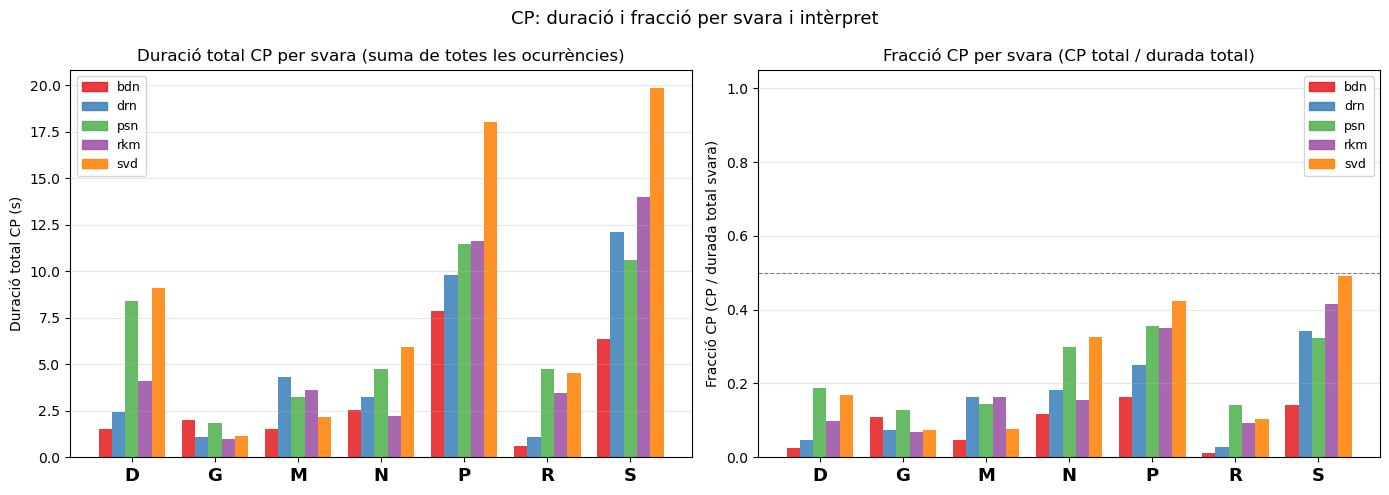

In [220]:
# Agregació: per (svara_label, performer) suma les durades
agg_rows = []
for sl in svara_labels:
    for perf in performers:
        sub = df.filter((pl.col('svara_label') == sl) & (pl.col('performer') == perf))
        if sub.is_empty():
            continue
        total_svara = float(sub['svara_dur_sec'].sum())
        total_cp    = float(sub['cp_total_dur_sec'].sum())
        total_sta   = float(sub['sta_total_dur_sec'].sum())
        agg_rows.append({
            'svara_label': sl,
            'performer':   perf,
            'total_svara': total_svara,
            'total_cp':    total_cp,
            'total_sta':   total_sta,
            'cp_frac':     total_cp  / total_svara if total_svara > 0 else 0.0,
            'sta_frac':    total_sta / total_svara if total_svara > 0 else 0.0,
        })

df_agg = pl.DataFrame(agg_rows)

# Helper per extreure el valor per (svara, performer)
def agg_val(sl, perf, col):
    row = df_agg.filter((pl.col('svara_label') == sl) & (pl.col('performer') == perf))
    return float(row[col][0]) if row.height > 0 else 0.0

bar_w = 0.8 / n_p
xi    = np.arange(n_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duració total CP
ax = axes[0]
for pi, perf in enumerate(performers):
    vals = [agg_val(sl, perf, 'total_cp') for sl in svara_labels]
    offset = (pi - n_p / 2 + 0.5) * bar_w
    ax.bar(xi + offset, vals, width=bar_w, color=COLORS.get(perf, 'gray'), label=perf, alpha=0.85)
ax.set_xticks(xi)
ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
ax.set_ylabel('Duració total CP (s)')
ax.set_title('Duració total CP per svara (suma de totes les ocurrències)')
ax.legend(handles=patches, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Fracció CP
ax = axes[1]
for pi, perf in enumerate(performers):
    vals = [agg_val(sl, perf, 'cp_frac') for sl in svara_labels]
    offset = (pi - n_p / 2 + 0.5) * bar_w
    ax.bar(xi + offset, vals, width=bar_w, color=COLORS.get(perf, 'gray'), label=perf, alpha=0.85)
ax.set_xticks(xi)
ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
ax.set_ylabel('Fracció CP (CP / durada total svara)')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', lw=0.8)
ax.set_title('Fracció CP per svara (CP total / durada total)')
ax.legend(handles=patches, fontsize=9)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('CP: duració i fracció per svara i intèrpret', fontsize=13)
plt.tight_layout()
plt.show()

### 2. Duració total i fracció STA per svara (sumats sobre totes les ocurrències)

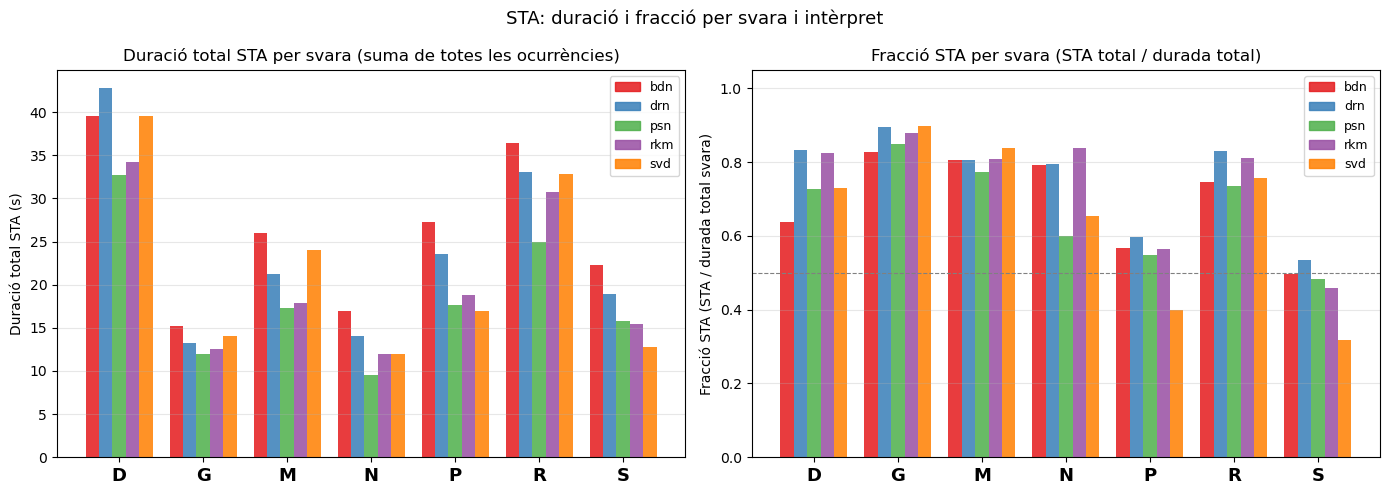

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duració total STA
ax = axes[0]
for pi, perf in enumerate(performers):
    vals = [agg_val(sl, perf, 'total_sta') for sl in svara_labels]
    offset = (pi - n_p / 2 + 0.5) * bar_w
    ax.bar(xi + offset, vals, width=bar_w, color=COLORS.get(perf, 'gray'), label=perf, alpha=0.85)
ax.set_xticks(xi)
ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
ax.set_ylabel('Duració total STA (s)')
ax.set_title('Duració total STA per svara (suma de totes les ocurrències)')
ax.legend(handles=patches, fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Fracció STA
ax = axes[1]
for pi, perf in enumerate(performers):
    vals = [agg_val(sl, perf, 'sta_frac') for sl in svara_labels]
    offset = (pi - n_p / 2 + 0.5) * bar_w
    ax.bar(xi + offset, vals, width=bar_w, color=COLORS.get(perf, 'gray'), label=perf, alpha=0.85)
ax.set_xticks(xi)
ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
ax.set_ylabel('Fracció STA (STA / durada total svara)')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, ls='--', color='gray', lw=0.8)
ax.set_title('Fracció STA per svara (STA total / durada total)')
ax.legend(handles=patches, fontsize=9)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('STA: duració i fracció per svara i intèrpret', fontsize=13)
plt.tight_layout()
plt.show()

### 3. CP + STA + SIL apilats per svara (fracció)

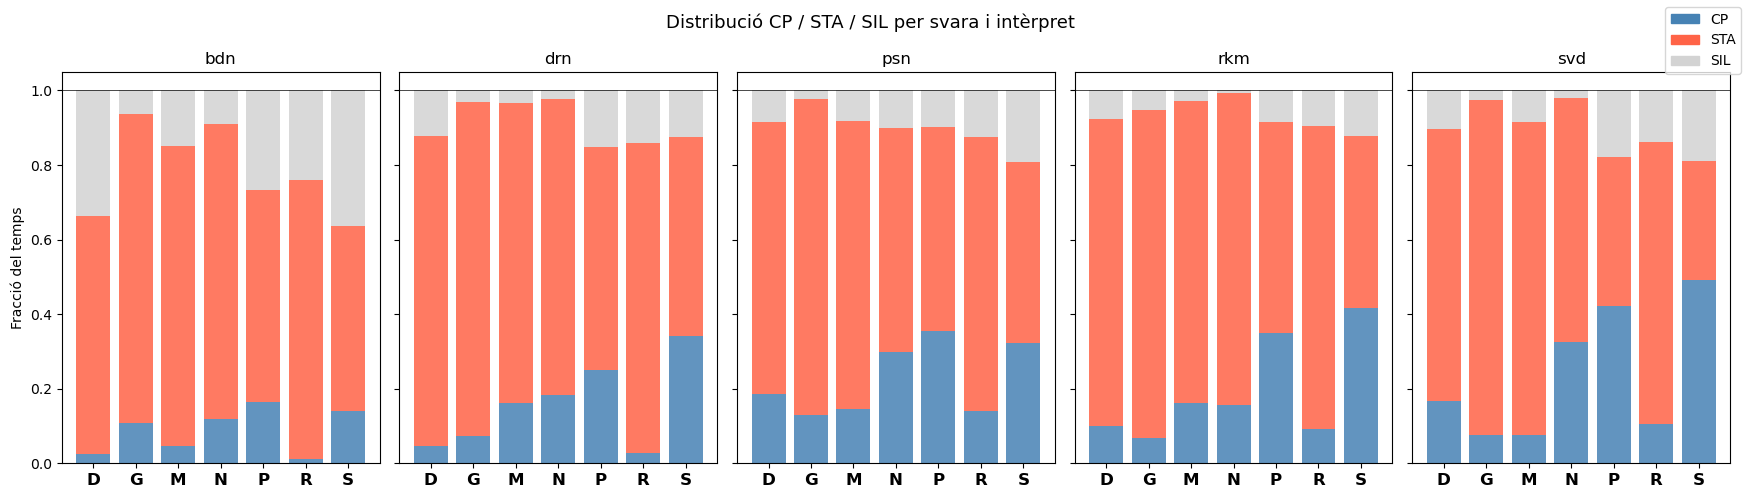

In [222]:
fig, axes = plt.subplots(1, n_p, figsize=(3.5 * n_p, 5), sharey=True)

for ax, perf in zip(axes, performers):
    cp_fracs  = [agg_val(sl, perf, 'cp_frac')  for sl in svara_labels]
    sta_fracs = [agg_val(sl, perf, 'sta_frac') for sl in svara_labels]
    sil_fracs = [max(0.0, 1.0 - c - s) for c, s in zip(cp_fracs, sta_fracs)]

    ax.bar(xi, cp_fracs,  label='CP',  color='steelblue',  alpha=0.85)
    ax.bar(xi, sta_fracs, label='STA', color='tomato',     alpha=0.85, bottom=cp_fracs)
    ax.bar(xi, sil_fracs, label='SIL', color='lightgray',  alpha=0.85,
           bottom=[c + s for c, s in zip(cp_fracs, sta_fracs)])

    ax.set_xticks(xi)
    ax.set_xticklabels(svara_labels, fontsize=12, fontweight='bold')
    ax.set_title(perf, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='black', lw=0.5)

axes[0].set_ylabel('Fracció del temps')
handles = [
    mpatches.Patch(color='steelblue', label='CP'),
    mpatches.Patch(color='tomato',    label='STA'),
    mpatches.Patch(color='lightgray', label='SIL'),
]
fig.legend(handles=handles, loc='upper right', fontsize=10)
fig.suptitle('Distribució CP / STA / SIL per svara i intèrpret', fontsize=13)
plt.tight_layout()
plt.show()

### 4. Distribució de cents CP per svara (KDE per intèrpret)

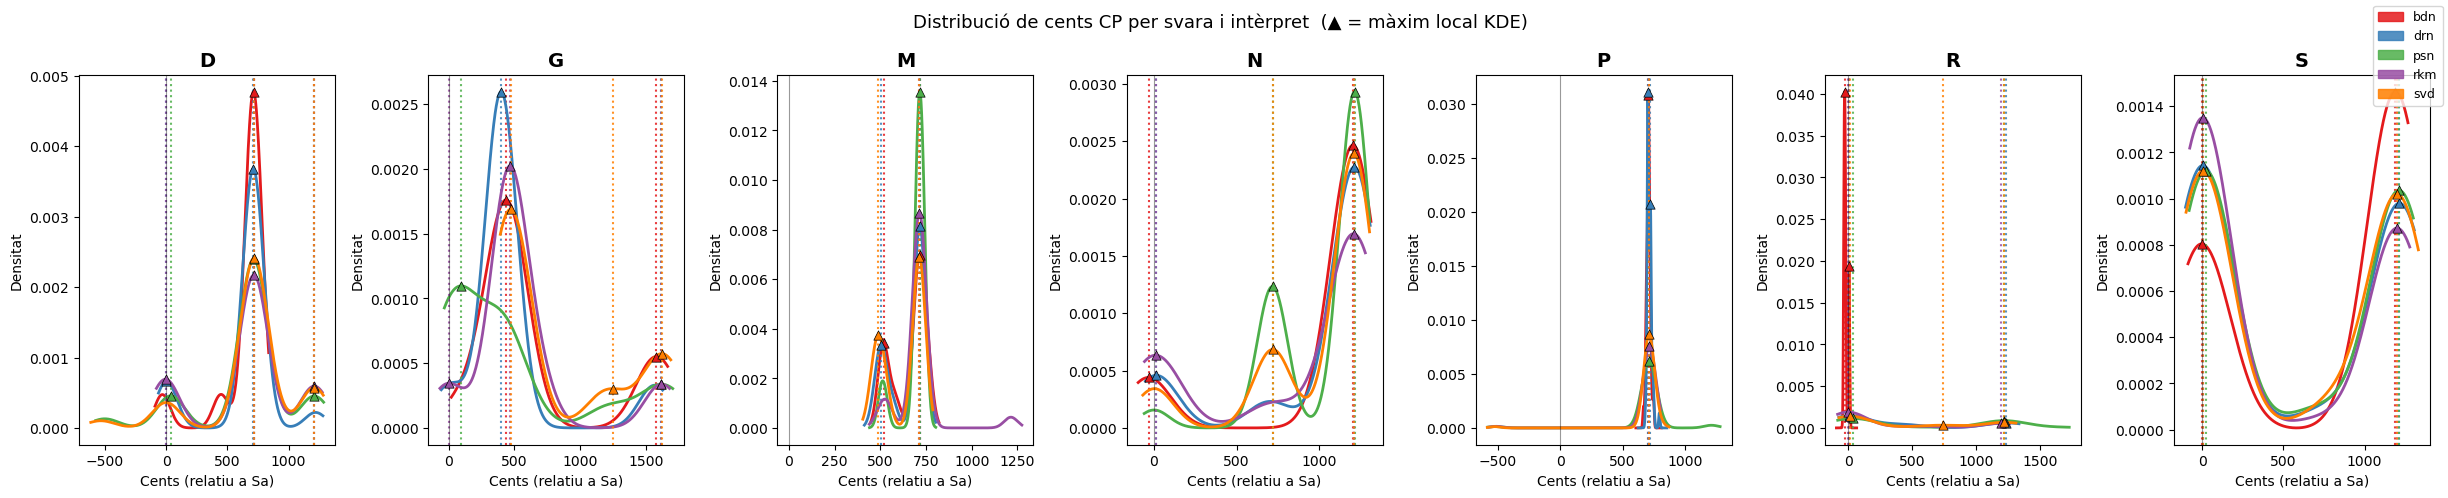

In [223]:
from scipy.signal import find_peaks

fig, axes = plt.subplots(1, n_s, figsize=(3.5 * n_s, 5), sharey=False)
if n_s == 1:
    axes = [axes]

for ax, sl in zip(axes, svara_labels):
    for perf in performers:
        cents_vals = []
        for r in all_rows:
            if r['svara_label'] == sl and r['performer'] == perf:
                cents_vals.extend(r['cp_cents_list'])
        if len(cents_vals) < 3:
            continue
        vals = np.array(cents_vals)
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            continue
        try:
            kde  = gaussian_kde(vals, bw_method=0.3)
            x    = np.linspace(vals.min() - 60, vals.max() + 60, 600)
            y    = kde(x)
            ax.plot(x, y, color=COLORS.get(perf, 'gray'), label=perf, linewidth=2)

            # Màxims locals: alçada ≥ 15% del pic global, separació ≥ 30 punts (~30 cents)
            peaks, _ = find_peaks(y, height=0.15 * y.max(), distance=30)
            for pk in peaks:
                ax.axvline(x[pk], color=COLORS.get(perf, 'gray'), ls=':', lw=1.5, alpha=0.85)
                ax.scatter(x[pk], y[pk], color=COLORS.get(perf, 'gray'),
                           s=45, zorder=5, marker='^', edgecolors='black', linewidths=0.5)
        except Exception:
            pass

    ax.set_title(sl, fontsize=14, fontweight='bold')
    ax.set_xlabel('Cents (relatiu a Sa)')
    ax.set_ylabel('Densitat')
    ax.axvline(0, color='black', lw=0.8, alpha=0.4)

fig.legend(handles=patches, loc='upper right', fontsize=9)
fig.suptitle('Distribució de cents CP per svara i intèrpret  (▲ = màxim local KDE)', fontsize=13)
plt.tight_layout()
plt.show()

### [D] Cents — STA: distribution per svara and performer
**Histogram + KDE** of STA segment pitch values.  
**Dashed** = peak-type STA (above svara mean CP cents) · **Dotted** = valley-type STA (below mean CP cents)

In [ ]:
fig, axes = plt.subplots(1, n_s, figsize=(3.5 * n_s, 5), sharey=False)
if n_s == 1:
    axes = [axes]

for ax, sl in zip(axes, svara_labels):
    for perf in performers:
        all_sta, peaks_c, valleys_c = [], [], []
        for r in all_rows:
            if r['svara_label'] == sl and r['performer'] == perf:
                all_sta.extend(r['sta_cents_list'])
                peaks_c.extend(r['sta_peak_cents_list'])
                valleys_c.extend(r['sta_valley_cents_list'])

        vals = np.array(all_sta)
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            continue

        color = COLORS.get(perf, 'gray')
        x     = np.linspace(vals.min() - 60, vals.max() + 60, 600)

        # histogram (density) behind KDE
        ax.hist(vals, bins=25, density=True, alpha=0.10, color=color, edgecolor='none')

        try:
            y = gaussian_kde(vals, bw_method=0.3)(x)
            ax.plot(x, y, color=color, label=perf, linewidth=2)
            peaks, _ = find_peaks(y, height=0.15 * y.max(), distance=30)
            for pk in peaks:
                ax.axvline(x[pk], color=color, ls=':', lw=1.5, alpha=0.85)
                ax.scatter(x[pk], y[pk], color=color, s=45, zorder=5,
                           marker='^', edgecolors='black', linewidths=0.5)
        except Exception:
            pass

        # peak-type STA (-- dashed, scaled to fraction of total)
        p_arr = np.array(peaks_c)[np.isfinite(np.array(peaks_c, dtype=float))]
        if len(p_arr) >= 3:
            try:
                yp = gaussian_kde(p_arr, bw_method=0.3)(x) * (len(p_arr) / len(vals))
                ax.plot(x, yp, color=color, ls='--', lw=1.2, alpha=0.6)
            except Exception:
                pass

        # valley-type STA (dotted)
        v_arr = np.array(valleys_c)[np.isfinite(np.array(valleys_c, dtype=float))]
        if len(v_arr) >= 3:
            try:
                yv = gaussian_kde(v_arr, bw_method=0.3)(x) * (len(v_arr) / len(vals))
                ax.plot(x, yv, color=color, ls=':', lw=1.2, alpha=0.6)
            except Exception:
                pass

    ax.set_title(sl, fontsize=14, fontweight='bold')
    ax.set_xlabel('Cents (relatiu a Sa)')
    ax.set_ylabel('Densitat')
    ax.axvline(0, color='black', lw=0.8, alpha=0.4)

fig.legend(handles=patches, loc='upper right', fontsize=9)
fig.suptitle('[D] STA cents — histogram + KDE per svara i intèrpret\n'
             '▲=màxim KDE  ——=peaks (above CP)  ⋯=valleys (below CP)', fontsize=12)
plt.tight_layout()
plt.show()

### [D] Cents — STA peak vs valley: stacked histogram per svara
One histogram per svara — orange = peak-type STA (above mean CP cents), blue = valley-type STA (below mean CP cents). All performers combined.

In [ ]:
COLOR_PEAK   = '#e6550d'   # orange = above CP (ornamental peak)
COLOR_VALLEY = '#3182bd'   # blue   = below CP (ornamental valley / dip)

fig, axes = plt.subplots(1, n_s, figsize=(3.5 * n_s, 5), sharey=False)
if n_s == 1:
    axes = [axes]

for ax, sl in zip(axes, svara_labels):
    all_peaks, all_valleys = [], []
    for r in all_rows:
        if r['svara_label'] == sl:
            all_peaks.extend(r['sta_peak_cents_list'])
            all_valleys.extend(r['sta_valley_cents_list'])

    p_arr = np.array(all_peaks,   dtype=float)
    v_arr = np.array(all_valleys, dtype=float)
    p_arr = p_arr[np.isfinite(p_arr)]
    v_arr = v_arr[np.isfinite(v_arr)]

    all_vals = np.concatenate([p_arr, v_arr])
    if len(all_vals) == 0:
        continue
    bins = np.linspace(all_vals.min() - 30, all_vals.max() + 30, 35)

    if len(p_arr):
        ax.hist(p_arr, bins=bins, density=False, color=COLOR_PEAK,
                alpha=0.65, edgecolor='white', linewidth=0.4, label='Peak (above CP)')
    if len(v_arr):
        ax.hist(v_arr, bins=bins, density=False, color=COLOR_VALLEY,
                alpha=0.65, edgecolor='white', linewidth=0.4, label='Valley (below CP)')

    # KDE overlays
    x = np.linspace(all_vals.min() - 60, all_vals.max() + 60, 500)
    scale_p = len(p_arr) * (bins[1] - bins[0])
    scale_v = len(v_arr) * (bins[1] - bins[0])
    try:
        if len(p_arr) >= 3:
            ax.plot(x, gaussian_kde(p_arr, bw_method=0.3)(x) * scale_p,
                    color=COLOR_PEAK, lw=2)
        if len(v_arr) >= 3:
            ax.plot(x, gaussian_kde(v_arr, bw_method=0.3)(x) * scale_v,
                    color=COLOR_VALLEY, lw=2)
    except Exception:
        pass

    ax.axvline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_title(sl, fontsize=14, fontweight='bold')
    ax.set_xlabel('Cents (relatiu a Sa)')
    ax.set_ylabel('Compte')
    n_p, n_v = len(p_arr), len(v_arr)
    ax.text(0.97, 0.97, f'peaks={n_p}\nvalleys={n_v}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

axes[0].legend(fontsize=9)
fig.suptitle('[D] STA peak vs valley — histogram per svara, tots els intèrprets combinats\n'
             'Peak = STA amb pitch > mean CP  |  Valley = STA amb pitch ≤ mean CP', fontsize=12)
plt.tight_layout()
plt.show()

### 6. Heatmap resum (per svara × intèrpret)

/tmp/ipykernel_9887/2979637421.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap_name).copy()
/tmp/ipykernel_9887/2979637421.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap_name).copy()
/tmp/ipykernel_9887/2979637421.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap_name).copy()
/tmp/ipykernel_9887/2979637421.py:55: MatplotlibDeprecationWarning: The get_cmap function w

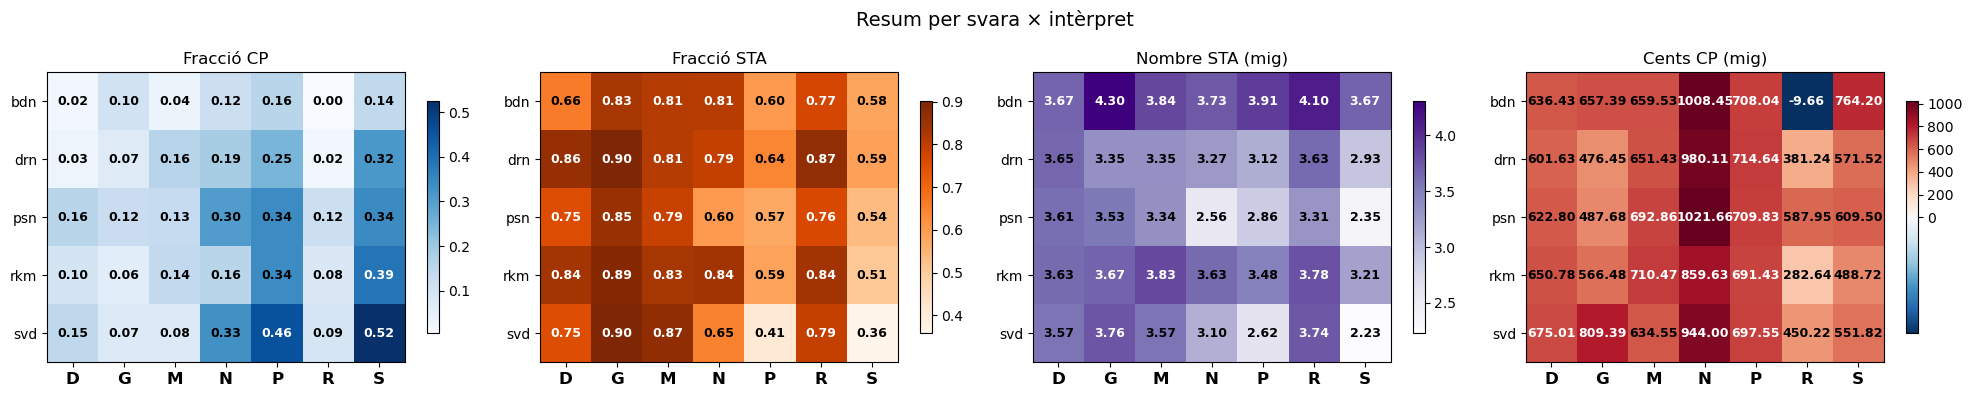

In [225]:
df_summary = (
    df
    .group_by(['svara_label', 'performer'])
    .agg([
        pl.col('svara_label').count().alias('n_occ'),
        pl.col('svara_dur_sec').mean().alias('mean_svara_dur'),
        pl.col('cp_total_dur_sec').mean().alias('mean_cp_dur'),
        pl.col('cp_frac').mean().alias('mean_cp_frac'),
        pl.col('sta_total_dur_sec').mean().alias('mean_sta_dur'),
        pl.col('sta_frac').mean().alias('mean_sta_frac'),
        pl.col('cp_mean_cents').drop_nans().mean().alias('mean_cp_cents'),
        pl.col('n_sta').mean().alias('mean_n_sta'),
        pl.col('sta_mean_cents').drop_nans().mean().alias('mean_sta_cents'),
    ])
    .sort(['svara_label', 'performer'])
)

metrics = [
    ('mean_cp_frac',  'Fracció CP',        'Blues',   False),
    ('mean_sta_frac', 'Fracció STA',        'Oranges', False),
    ('mean_n_sta',    'Nombre STA (mig)',   'Purples', False),
    ('mean_cp_cents', 'Cents CP (mig)',     'RdBu_r',  True),
]

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4))

for ax, (col, title, cmap_name, diverging) in zip(axes, metrics):
    mat = np.full((len(performers), len(svara_labels)), np.nan)
    for i, perf in enumerate(performers):
        for j, sl in enumerate(svara_labels):
            row = df_summary.filter(
                (pl.col('performer') == perf) & (pl.col('svara_label') == sl)
            )
            if row.height > 0:
                val = row[col][0]
                if val is not None and not (isinstance(val, float) and np.isnan(val)):
                    mat[i, j] = float(val)

    finite_vals = mat[np.isfinite(mat)]
    if len(finite_vals) == 0:
        ax.set_title(f'{title}\n(sense dades)')
        ax.set_xticks(range(len(svara_labels)))
        ax.set_xticklabels(svara_labels, fontsize=12, fontweight='bold')
        ax.set_yticks(range(len(performers)))
        ax.set_yticklabels(performers)
        continue

    if diverging:
        vmin = min(float(np.nanmin(mat)), -1e-6)
        vmax = max(float(np.nanmax(mat)),  1e-6)
        norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=vmin, vmax=vmax)
    else:
        norm = mcolors.Normalize(vmin=float(np.nanmin(mat)), vmax=float(np.nanmax(mat)))

    cmap_obj = cm.get_cmap(cmap_name).copy()
    cmap_obj.set_bad('lightgray')
    im = ax.imshow(mat, aspect='auto', cmap=cmap_obj, norm=norm)
    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=12, fontweight='bold')
    ax.set_yticks(range(len(performers)))
    ax.set_yticklabels(performers)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

    for i in range(len(performers)):
        for j in range(len(svara_labels)):
            v = mat[i, j]
            if not np.isfinite(v):
                continue
            rgba = cmap_obj(norm(v))
            lum  = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                    fontweight='bold', color='black' if lum > 0.45 else 'white')

fig.suptitle('Resum per svara × intèrpret', fontsize=14)
plt.tight_layout()
plt.show()

### 7. CP individual — durada de cada segment CP (1 punt = 1 segment CP)

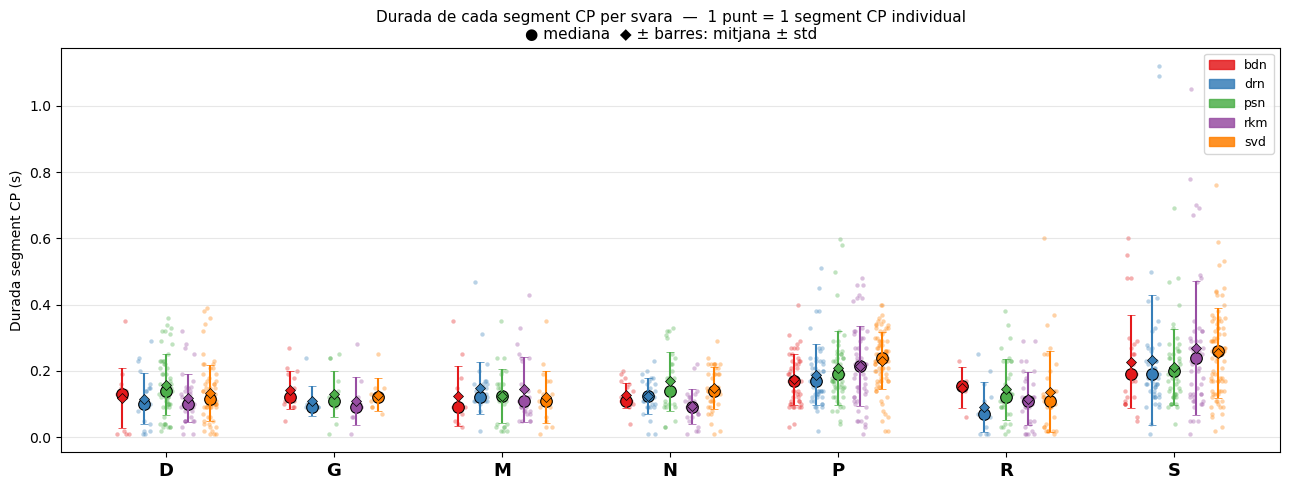

In [226]:
# CP individual: 1 punt = 1 segment CP
fig, ax = plt.subplots(figsize=(13, 5))

for xi, sl in enumerate(svara_labels):
    for pi, perf in enumerate(performers):
        durs = []
        for r in all_rows:
            if r['svara_label'] == sl and r['performer'] == perf:
                durs.extend(r['cp_dur_list'])
        if not durs:
            continue
        vals = np.array(durs)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if len(vals) == 0:
            continue

        x_off = xi + (pi - (n_p - 1) / 2) * 0.13
        jitter = np.random.default_rng(hash(perf + 'cp_ind_dur') % 2**32).uniform(-0.04, 0.04, size=len(vals))
        ax.scatter(x_off + jitter, vals, color=COLORS.get(perf, 'gray'), alpha=0.35, s=10, linewidths=0)

        med = np.median(vals)
        m   = np.mean(vals)
        s   = np.std(vals)
        ax.scatter(x_off, med, color=COLORS.get(perf, 'gray'), s=70, zorder=5,
                   edgecolors='black', linewidths=0.8, marker='o')
        ax.errorbar(x_off, m, yerr=s, fmt='D', color=COLORS.get(perf, 'gray'),
                    markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.5)

ax.set_xticks(range(len(svara_labels)))
ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
ax.set_xlim(-0.5, n_s - 0.5)
ax.set_ylabel('Durada segment CP (s)')
ax.set_title('Durada de cada segment CP per svara  —  1 punt = 1 segment CP individual\n'
             '● mediana  ◆ ± barres: mitjana ± std', fontsize=11)
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 8. CP per svara anotat — durada total i fracció (1 punt = 1 svara, suma dels CP interns)

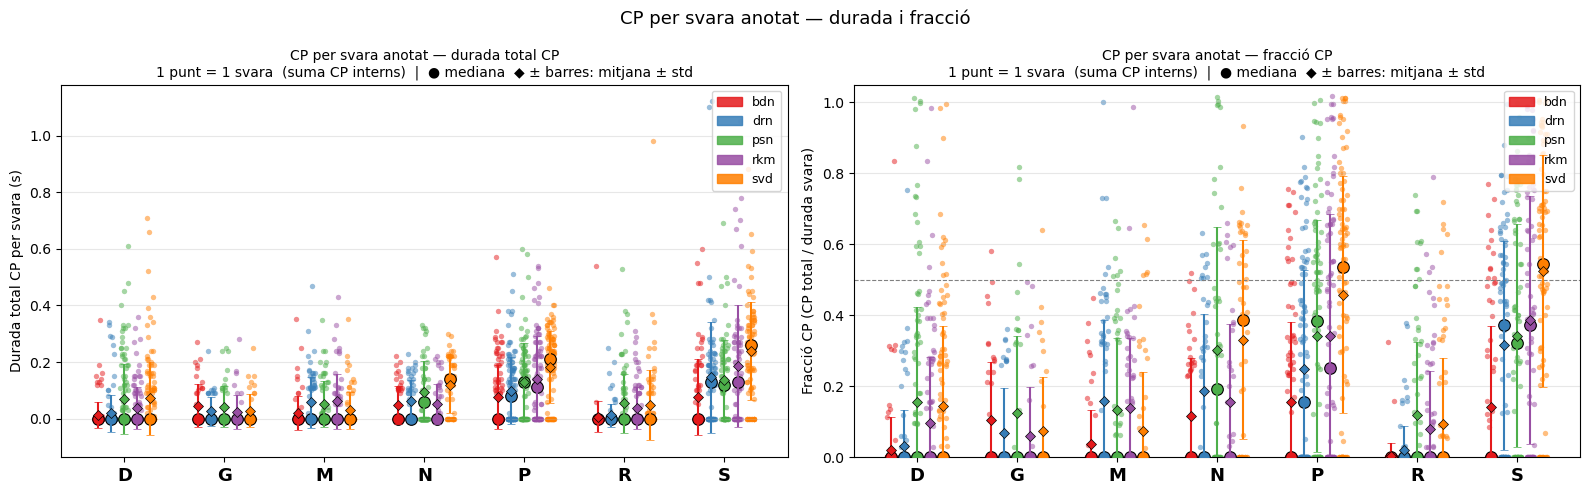

In [227]:
# CP per ocurrència: 1 punt = 1 svara anotada (suma dels CP interns)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, ylabel, title_suffix in [
    (axes[0], 'cp_total_dur_sec', 'Durada total CP per svara (s)', 'durada total CP'),
    (axes[1], 'cp_frac',          'Fracció CP (CP total / durada svara)', 'fracció CP'),
]:
    for xi, sl in enumerate(svara_labels):
        for pi, perf in enumerate(performers):
            sub  = df.filter((pl.col('svara_label') == sl) & (pl.col('performer') == perf))
            vals = sub[col].to_numpy()
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue

            x_off = xi + (pi - (n_p - 1) / 2) * 0.13
            jitter = np.random.default_rng(hash(perf + col) % 2**32).uniform(-0.04, 0.04, size=len(vals))
            ax.scatter(x_off + jitter, vals, color=COLORS.get(perf, 'gray'), alpha=0.5, s=15, linewidths=0)

            med = np.median(vals)
            m   = np.mean(vals)
            s   = np.std(vals)
            ax.scatter(x_off, med, color=COLORS.get(perf, 'gray'), s=70, zorder=5,
                       edgecolors='black', linewidths=0.8, marker='o')
            ax.errorbar(x_off, m, yerr=s, fmt='D', color=COLORS.get(perf, 'gray'),
                        markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=6,
                        markeredgecolor='black', markeredgewidth=0.5)

    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f'CP per svara anotat — {title_suffix}\n'
                 '1 punt = 1 svara  (suma CP interns)  |  ● mediana  ◆ ± barres: mitjana ± std', fontsize=10)
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if col == 'cp_frac':
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, ls='--', color='gray', lw=0.8)

fig.suptitle('CP per svara anotat — durada i fracció', fontsize=13)
plt.tight_layout()
plt.show()

### 9. STA individual — durada de cada segment STA (1 punt = 1 segment STA)

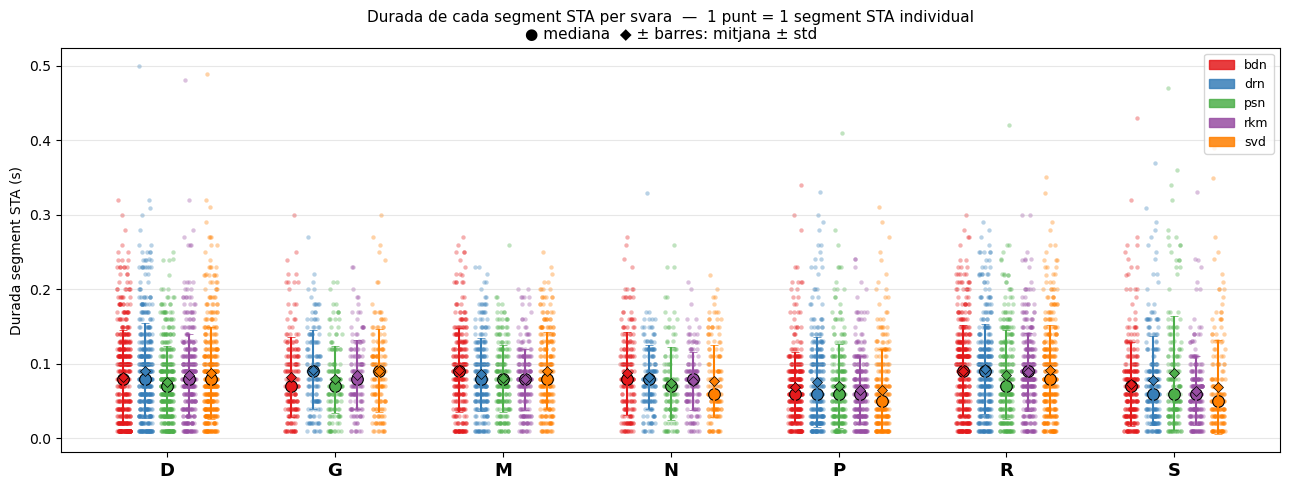

In [228]:
# STA individual: 1 punt = 1 segment STA
fig, ax = plt.subplots(figsize=(13, 5))

for xi, sl in enumerate(svara_labels):
    for pi, perf in enumerate(performers):
        durs = []
        for r in all_rows:
            if r['svara_label'] == sl and r['performer'] == perf:
                durs.extend(r['sta_dur_list'])
        if not durs:
            continue
        vals = np.array(durs)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if len(vals) == 0:
            continue

        x_off = xi + (pi - (n_p - 1) / 2) * 0.13
        jitter = np.random.default_rng(hash(perf + 'sta_ind_dur') % 2**32).uniform(-0.04, 0.04, size=len(vals))
        ax.scatter(x_off + jitter, vals, color=COLORS.get(perf, 'gray'), alpha=0.35, s=10, linewidths=0)

        med = np.median(vals)
        m   = np.mean(vals)
        s   = np.std(vals)
        ax.scatter(x_off, med, color=COLORS.get(perf, 'gray'), s=70, zorder=5,
                   edgecolors='black', linewidths=0.8, marker='o')
        ax.errorbar(x_off, m, yerr=s, fmt='D', color=COLORS.get(perf, 'gray'),
                    markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.5)

ax.set_xticks(range(len(svara_labels)))
ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
ax.set_xlim(-0.5, n_s - 0.5)
ax.set_ylabel('Durada segment STA (s)')
ax.set_title('Durada de cada segment STA per svara  —  1 punt = 1 segment STA individual\n'
             '● mediana  ◆ ± barres: mitjana ± std', fontsize=11)
ax.legend(handles=patches, loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 10. STA per svara anotat — durada total i fracció (1 punt = 1 svara, suma dels STA interns)

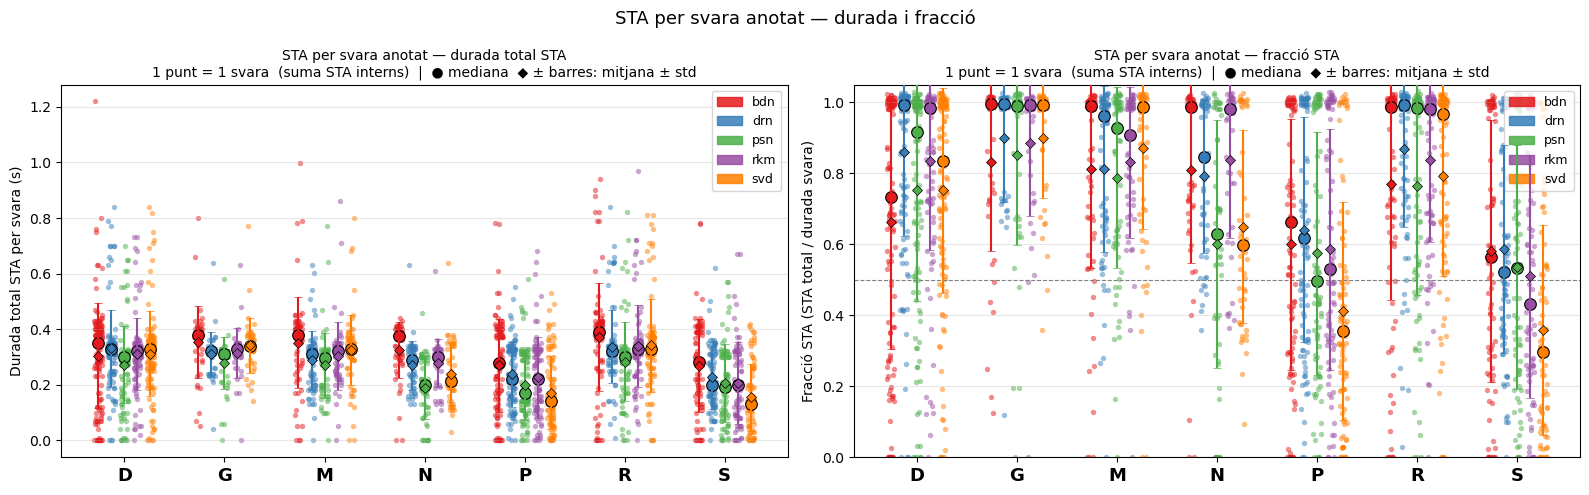

In [229]:
# STA per ocurrència: 1 punt = 1 svara anotada (suma dels STA interns)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, ylabel, title_suffix in [
    (axes[0], 'sta_total_dur_sec', 'Durada total STA per svara (s)', 'durada total STA'),
    (axes[1], 'sta_frac',          'Fracció STA (STA total / durada svara)', 'fracció STA'),
]:
    for xi, sl in enumerate(svara_labels):
        for pi, perf in enumerate(performers):
            sub  = df.filter((pl.col('svara_label') == sl) & (pl.col('performer') == perf))
            vals = sub[col].to_numpy()
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue

            x_off = xi + (pi - (n_p - 1) / 2) * 0.13
            jitter = np.random.default_rng(hash(perf + col + 'sta') % 2**32).uniform(-0.04, 0.04, size=len(vals))
            ax.scatter(x_off + jitter, vals, color=COLORS.get(perf, 'gray'), alpha=0.5, s=15, linewidths=0)

            med = np.median(vals)
            m   = np.mean(vals)
            s   = np.std(vals)
            ax.scatter(x_off, med, color=COLORS.get(perf, 'gray'), s=70, zorder=5,
                       edgecolors='black', linewidths=0.8, marker='o')
            ax.errorbar(x_off, m, yerr=s, fmt='D', color=COLORS.get(perf, 'gray'),
                        markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=6,
                        markeredgecolor='black', markeredgewidth=0.5)

    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(f'STA per svara anotat — {title_suffix}\n'
                 '1 punt = 1 svara  (suma STA interns)  |  ● mediana  ◆ ± barres: mitjana ± std', fontsize=10)
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    if col == 'sta_frac':
        ax.set_ylim(0, 1.05)
        ax.axhline(0.5, ls='--', color='gray', lw=0.8)

fig.suptitle('STA per svara anotat — durada i fracció', fontsize=13)
plt.tight_layout()
plt.show()

### 11. Cents CP i STA per svara i intèrpret — 1 punt = 1 segment

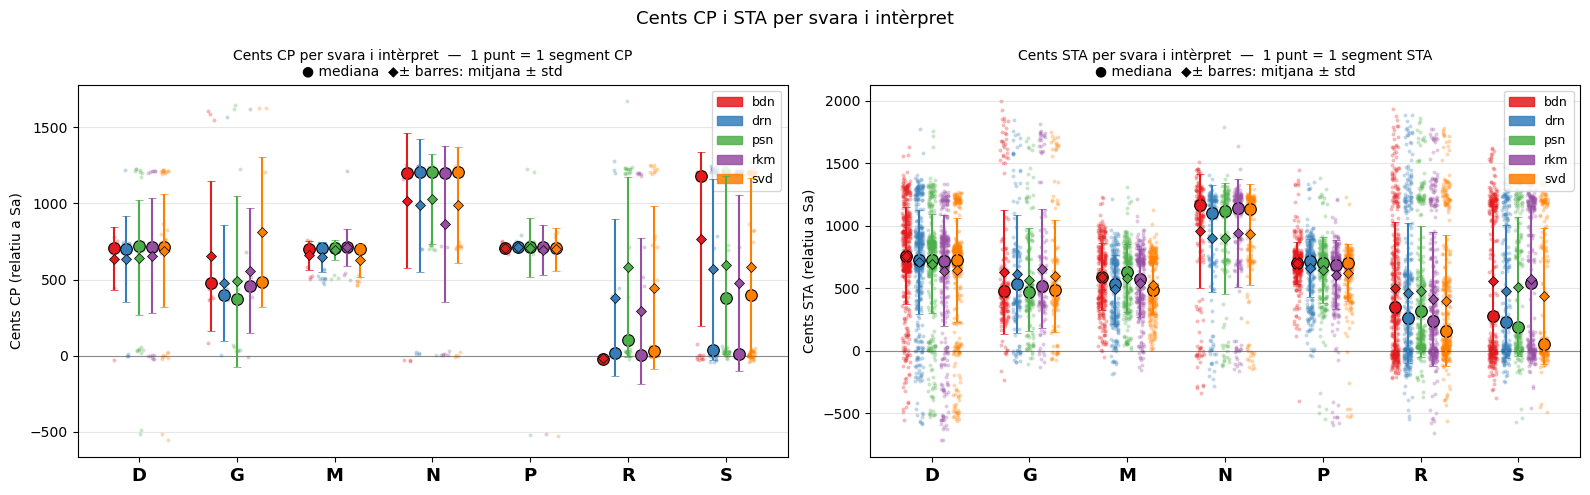

In [230]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, cents_key, seg_type in [
    (axes[0], 'cp_cents_list',  'CP'),
    (axes[1], 'sta_cents_list', 'STA'),
]:
    for xi, sl in enumerate(svara_labels):
        for pi, perf in enumerate(performers):
            cents_vals = []
            for r in all_rows:
                if r['svara_label'] == sl and r['performer'] == perf:
                    cents_vals.extend(r[cents_key])
            vals = np.array(cents_vals, dtype=float)
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue

            x_off  = xi + (pi - (n_p - 1) / 2) * 0.13
            jitter = np.random.default_rng(hash(perf + cents_key + sl) % 2**32).uniform(-0.04, 0.04, size=len(vals))
            ax.scatter(x_off + jitter, vals, color=COLORS.get(perf, 'gray'), alpha=0.3, s=8, linewidths=0)

            med, m, s = np.median(vals), np.mean(vals), np.std(vals)
            ax.scatter(x_off, med, color=COLORS.get(perf, 'gray'), s=70, zorder=5,
                       edgecolors='black', linewidths=0.8, marker='o')
            ax.errorbar(x_off, m, yerr=s, fmt='D', color=COLORS.get(perf, 'gray'),
                        markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=6,
                        markeredgecolor='black', markeredgewidth=0.5)

    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(f'Cents {seg_type} (relatiu a Sa)')
    ax.set_title(f'Cents {seg_type} per svara i intèrpret  —  1 punt = 1 segment {seg_type}\n'
                 '● mediana  ◆± barres: mitjana ± std', fontsize=10)
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Cents CP i STA per svara i intèrpret', fontsize=13)
plt.tight_layout()
plt.show()

### [C] Run-level analysis — per performer
A **run** = maximal contiguous block of same-type segments within a svara.  
e.g. `CP-CP-STA-STA-CP` → CP_run₁, STA_run₁, CP_run₂

Each dot = duration of one run. Colored by performer.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, run_key, seg_type in [
    (axes[0], 'cp_run_dur_list',  'CP'),
    (axes[1], 'sta_run_dur_list', 'STA'),
]:
    for xi, sl in enumerate(svara_labels):
        for pi, perf in enumerate(performers):
            run_durs = []
            for r in all_rows:
                if r['svara_label'] == sl and r['performer'] == perf:
                    run_durs.extend(r[run_key])
            vals = np.array(run_durs, dtype=float)
            vals = vals[np.isfinite(vals) & (vals > 0)]
            if len(vals) == 0:
                continue

            x_off  = xi + (pi - (n_p - 1) / 2) * 0.13
            jitter = np.random.default_rng(hash(perf + run_key + sl) % 2**32).uniform(-0.04, 0.04, size=len(vals))
            ax.scatter(x_off + jitter, vals, color=COLORS.get(perf, 'gray'),
                       alpha=0.35, s=10, linewidths=0)
            med, m, s = np.median(vals), np.mean(vals), np.std(vals)
            ax.scatter(x_off, med, color=COLORS.get(perf, 'gray'), s=70, zorder=5,
                       edgecolors='black', linewidths=0.8, marker='o')
            ax.errorbar(x_off, m, yerr=s, fmt='D', color=COLORS.get(perf, 'gray'),
                        markersize=5, capsize=3, capthick=1.5, elinewidth=1.5, zorder=6,
                        markeredgecolor='black', markeredgewidth=0.5)

    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(f'Durada del run {seg_type} (s)')
    ax.set_title(f'[C] {seg_type} run duration  —  1 punt = 1 contiguous {seg_type} block\n'
                 '● mediana  ◆± barres: mitjana ± std', fontsize=10)
    ax.legend(handles=patches, loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('[C] Run duration per svara i intèrpret — CP i STA', fontsize=13)
plt.tight_layout()
plt.show()

## Exportació

## Structural Embedding — 5 gravacions combinades (sense desglossar)

In [231]:
from src.features.structural_embedding import structural_embedding_one_recording

# Carrega (o recalcula) les embeddings per a les 5 gravacions i les concatena
dfs = []
for rec in RECORDINGS:
    df_emb = structural_embedding_one_recording(
        recording_id=rec,
        tonic_hz=S.SARASUDA_TONICS[rec],
        corpus_root=PROJECT_ROOT / 'data/corpus',
        interim_root=PROJECT_ROOT / 'data/interim',
        max_segments=12,
        tau_init_sil=TAU_INIT_SIL,
    )
    dfs.append(df_emb)

df_emb_all = pl.concat(dfs)
print(f'Total embeddings: {df_emb_all.shape[0]} svaras  ×  {df_emb_all.shape[1]} columnes')
df_emb_all.head(5)

Structural embeddings saved: data/interim/srs_v1_bdn_sav/features/srs_v1_bdn_sav_svara_structural_embeddings.parquet
Structural embeddings saved: data/interim/srs_v1_drn_sav/features/srs_v1_drn_sav_svara_structural_embeddings.parquet
Structural embeddings saved: data/interim/srs_v1_psn_sav/features/srs_v1_psn_sav_svara_structural_embeddings.parquet
Structural embeddings saved: data/interim/srs_v1_rkm_sav/features/srs_v1_rkm_sav_svara_structural_embeddings.parquet
Structural embeddings saved: data/interim/srs_v1_svd_sav/features/srs_v1_svd_sav_svara_structural_embeddings.parquet
Total embeddings: 2760 svaras  ×  9 columnes


recording_id,segment_id,svara_label,t_start,t_end,duration_sec,n_rows,n_segments,embedding
str,i64,str,f64,f64,f64,i64,i64,list[f64]
"""srs_v1_bdn_sav""",0,"""S""",3.806,4.757,0.951,95,11,"[0.940059, 0.0, … 0.0]"
"""srs_v1_bdn_sav""",1,"""R""",4.757,5.593,0.836,84,8,"[0.830052, 0.0, … 0.0]"
"""srs_v1_bdn_sav""",2,"""G""",5.593,6.466,0.873,87,10,"[0.860054, 0.0, … 0.0]"
"""srs_v1_bdn_sav""",3,"""R""",6.466,6.899,0.433,43,3,"[0.420027, 0.0, … 0.0]"
"""srs_v1_bdn_sav""",4,"""G""",6.899,7.332,0.433,44,6,"[0.430027, 0.0, … 0.0]"


In [232]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Extreu matriu d'embeddings (llista → array 2D)
X_raw   = np.array(df_emb_all['embedding'].to_list(), dtype=float)
labels  = np.array(df_emb_all['svara_label'].to_list())
rec_ids = np.array(df_emb_all['recording_id'].to_list())
perfs   = np.array([r.split('_')[2] for r in rec_ids])

# Filtra files amb algun NaN
valid = np.all(np.isfinite(X_raw), axis=1)
X       = X_raw[valid]
labels  = labels[valid]
rec_ids = rec_ids[valid]
perfs   = perfs[valid]

print(f'Embeddings totals: {X_raw.shape[0]}  |  vàlids (sense NaN): {X.shape[0]}  |  descartats: {(~valid).sum()}')
print(f'Shape X: {X.shape}')

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)
pca    = PCA(n_components=2, random_state=0)
X_2d   = pca.fit_transform(X_sc)
print(f'Variància explicada: PC1={pca.explained_variance_ratio_[0]:.1%}  PC2={pca.explained_variance_ratio_[1]:.1%}')

Embeddings totals: 2760  |  vàlids (sense NaN): 2696  |  descartats: 64
Shape X: (2696, 61)
Variància explicada: PC1=16.2%  PC2=7.5%


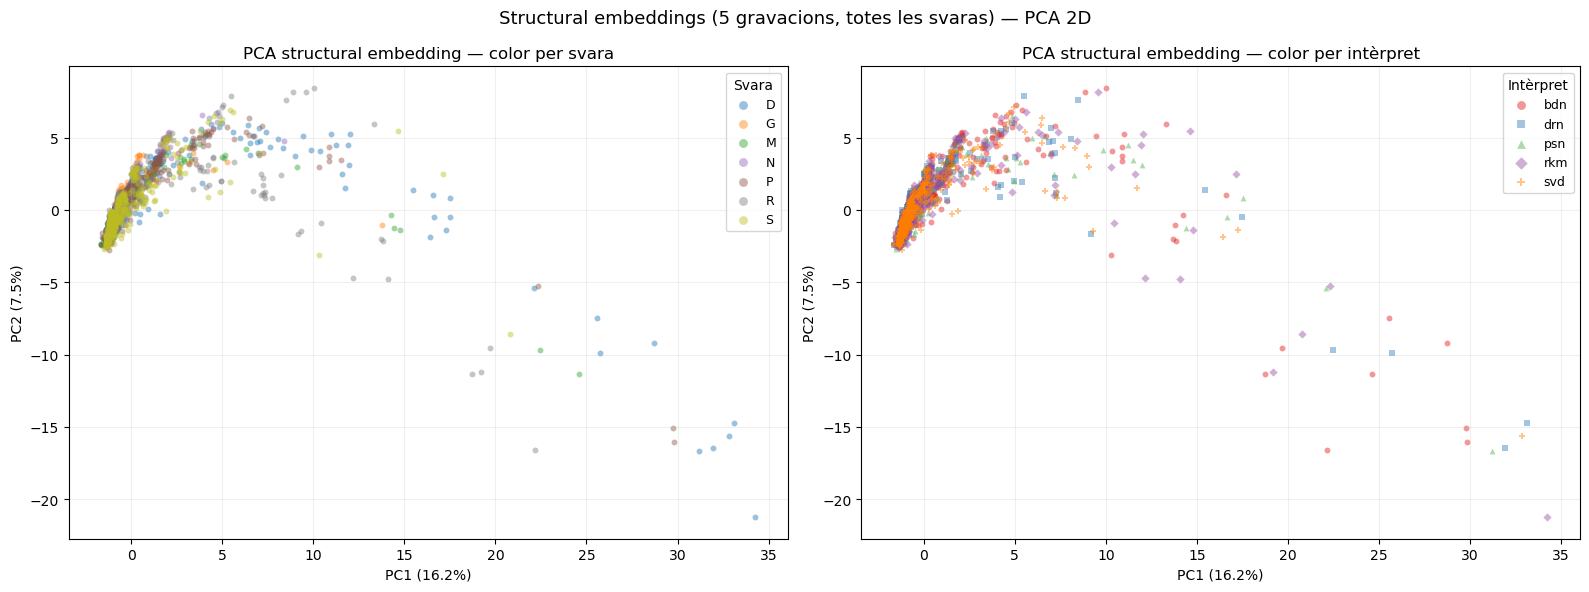

In [233]:
# Colors per svara_label (consistent amb la raga Saveri: S R G M P D N)
SVARA_COLORS = {sl: plt.cm.tab10(i / max(len(svara_labels), 1))
                for i, sl in enumerate(svara_labels)}
MARKERS = {'bdn': 'o', 'drn': 's', 'psn': '^', 'rkm': 'D', 'svd': 'P'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# — Plot A: colorejat per svara_label —
ax = axes[0]
for sl in svara_labels:
    mask = np.array([l == sl for l in labels])
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=SVARA_COLORS[sl], alpha=0.45, s=18, label=sl, linewidths=0)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA structural embedding — color per svara')
ax.legend(title='Svara', fontsize=9, markerscale=1.5)
ax.grid(alpha=0.2)

# — Plot B: colorejat per intèrpret —
ax = axes[1]
for perf in performers:
    mask = np.array([p == perf for p in perfs])
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=COLORS.get(perf, 'gray'), alpha=0.45, s=18,
               marker=MARKERS.get(perf, 'o'), label=perf, linewidths=0)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA structural embedding — color per intèrpret')
ax.legend(title='Intèrpret', fontsize=9, markerscale=1.5)
ax.grid(alpha=0.2)

fig.suptitle('Structural embeddings (5 gravacions, totes les svaras) — PCA 2D', fontsize=13)
plt.tight_layout()
plt.show()

### PCA per svara (sense desglossar per intèrpret)

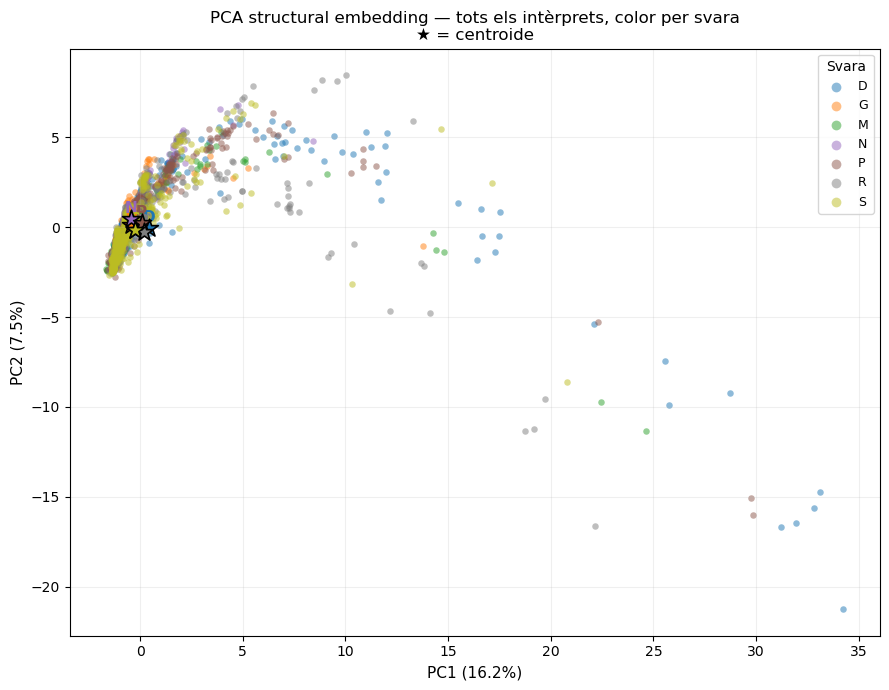

In [234]:
# Plot gran: tots els punts colorejats per svara, tots els intèrprets junts
fig, ax = plt.subplots(figsize=(9, 7))

for sl in svara_labels:
    mask = labels == sl
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=SVARA_COLORS[sl], alpha=0.5, s=22, label=sl, linewidths=0)
    # Centroide
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.scatter(cx, cy, color=SVARA_COLORS[sl], s=180, zorder=6,
               edgecolors='black', linewidths=1.2, marker='*')
    ax.text(cx, cy + 0.15, sl, ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=SVARA_COLORS[sl])

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_title('PCA structural embedding — tots els intèrprets, color per svara\n★ = centroide', fontsize=12)
ax.legend(title='Svara', fontsize=9, markerscale=1.5)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

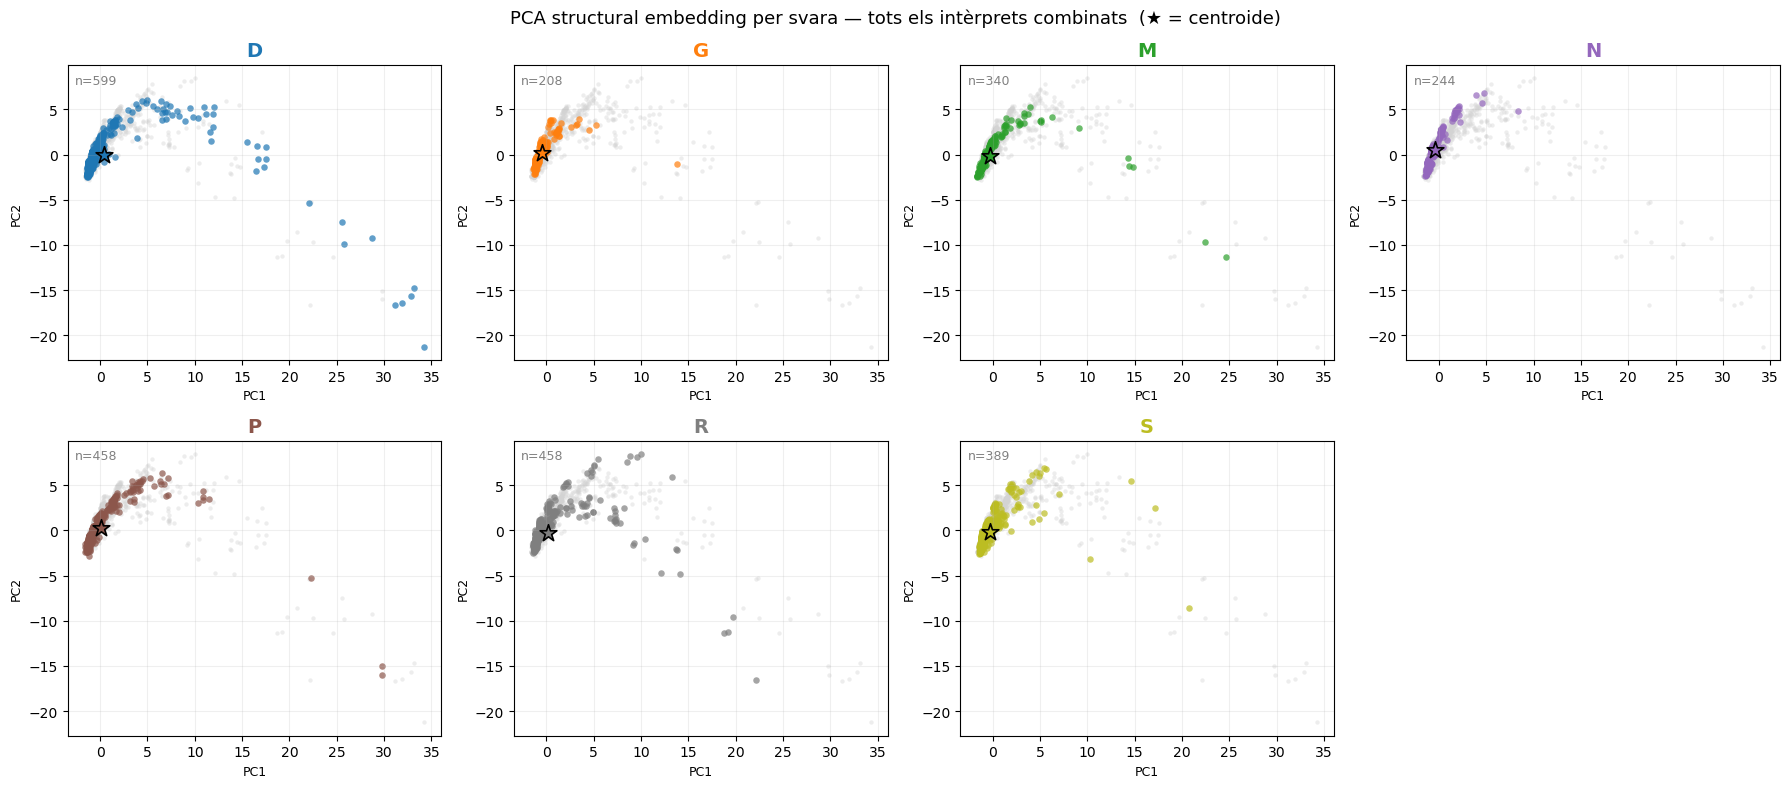

In [235]:
# Grid: un subplot per svara — fons gris (resta) + color (svara destacada)
ncols = min(n_s, 4)
nrows = int(np.ceil(n_s / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), squeeze=False)

for idx, sl in enumerate(svara_labels):
    ax  = axes[idx // ncols][idx % ncols]
    mask = labels == sl

    # Fons: tots els altres punts en gris clar
    ax.scatter(X_2d[~mask, 0], X_2d[~mask, 1],
               color='lightgray', alpha=0.4, s=10, linewidths=0)
    # Svara destacada
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=SVARA_COLORS[sl], alpha=0.7, s=22, linewidths=0)
    # Centroide
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax.scatter(cx, cy, color=SVARA_COLORS[sl], s=160, zorder=5,
               edgecolors='black', linewidths=1.2, marker='*')

    ax.set_title(sl, fontsize=14, fontweight='bold', color=SVARA_COLORS[sl])
    ax.set_xlabel(f'PC1', fontsize=9)
    ax.set_ylabel(f'PC2', fontsize=9)
    ax.grid(alpha=0.2)
    ax.text(0.02, 0.97, f'n={mask.sum()}', transform=ax.transAxes,
            fontsize=9, va='top', color='gray')

# Amaga subplots buits
for idx in range(n_s, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle('PCA structural embedding per svara — tots els intèrprets combinats  (★ = centroide)', fontsize=13)
plt.tight_layout()
plt.show()

In [236]:
out_dir = PROJECT_ROOT / 'data' / 'processed'
out_dir.mkdir(parents=True, exist_ok=True)

# Extreu codi de peça i raga del primer ID (tots comparteixen peça i raga)
_parts     = RECORDINGS[0].split('_')
piece_code = _parts[0]   # 'srs'
raga_code  = _parts[3]   # 'sav'
tag        = f'{piece_code}_{raga_code}'

df.write_parquet(out_dir / f'svara_structural_summary_{tag}.parquet')
df_agg.write_csv(out_dir / f'svara_structural_agg_{tag}.csv', separator='\t')
print(f'Tag: {tag}')
print(f'Desat: {out_dir}')

Tag: srs_sav
Desat: /home/lluis/master-thesis/CSISD/data/processed


---
## Anàlisi per svara — tots els intèrprets combinats

Mateixos indicadors (CP/STA durades, fraccions, KDE cents) però sense distingir gravació ni intèrpret. Cada svara agrupa totes les ocurrències de les 5 gravacions.

In [237]:
def _scatter_combined(ax, vals_per_svara, ylabel, title, ylim=None, hline=None):
    """Scatter combinat (tots els intèrprets junts): punts + mediana + mitjana±std."""
    for xi, sl in enumerate(svara_labels):
        vals = np.array(vals_per_svara[sl])
        vals = vals[np.isfinite(vals) & (vals >= 0)]
        if len(vals) == 0:
            continue
        jitter = np.random.default_rng(hash(sl + title) % 2**32).uniform(-0.2, 0.2, size=len(vals))
        ax.scatter(xi + jitter, vals, color=SVARA_COLORS[sl], alpha=0.35, s=12, linewidths=0)
        med, m, s = np.median(vals), np.mean(vals), np.std(vals)
        ax.scatter(xi, med, color=SVARA_COLORS[sl], s=80, zorder=5,
                   edgecolors='black', linewidths=0.9, marker='o')
        ax.errorbar(xi, m, yerr=s, fmt='D', color=SVARA_COLORS[sl],
                    markersize=6, capsize=4, capthick=1.5, elinewidth=1.5, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.6)
    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    if ylim:
        ax.set_ylim(*ylim)
    if hline is not None:
        ax.axhline(hline, ls='--', color='gray', lw=0.8)

In [238]:
# Prepara dicts: svara → llista de valors (de totes les gravacions)
cp_ind_durs  = {sl: [] for sl in svara_labels}   # 1 valor per segment CP
sta_ind_durs = {sl: [] for sl in svara_labels}   # 1 valor per segment STA
cp_occ_durs  = {sl: [] for sl in svara_labels}   # 1 valor per svara anotada
sta_occ_durs = {sl: [] for sl in svara_labels}
cp_occ_frac  = {sl: [] for sl in svara_labels}
sta_occ_frac = {sl: [] for sl in svara_labels}
cp_cents_comb  = {sl: [] for sl in svara_labels}
sta_cents_comb = {sl: [] for sl in svara_labels}

for r in all_rows:
    sl = r['svara_label']
    if sl not in svara_labels:
        continue
    cp_ind_durs[sl].extend(r['cp_dur_list'])
    sta_ind_durs[sl].extend(r['sta_dur_list'])
    cp_occ_durs[sl].append(r['cp_total_dur_sec'])
    sta_occ_durs[sl].append(r['sta_total_dur_sec'])
    cp_occ_frac[sl].append(r['cp_frac'])
    sta_occ_frac[sl].append(r['sta_frac'])
    cp_cents_comb[sl].extend(r['cp_cents_list'])
    sta_cents_comb[sl].extend(r['sta_cents_list'])

print('Dades preparades. Ocurrències per svara:')
for sl in svara_labels:
    print(f'  {sl}: {len(cp_occ_durs[sl])} ocurrències, '
          f'{len(cp_ind_durs[sl])} seg CP, {len(sta_ind_durs[sl])} seg STA')

Dades preparades. Ocurrències per svara:
  D: 616 ocurrències, 190 seg CP, 2233 seg STA
  G: 210 ocurrències, 56 seg CP, 782 seg STA
  M: 345 ocurrències, 110 seg CP, 1236 seg STA
  N: 247 ocurrències, 138 seg CP, 803 seg STA
  P: 470 ocurrències, 284 seg CP, 1504 seg STA
  R: 471 ocurrències, 112 seg CP, 1752 seg STA
  S: 401 ocurrències, 260 seg CP, 1155 seg STA


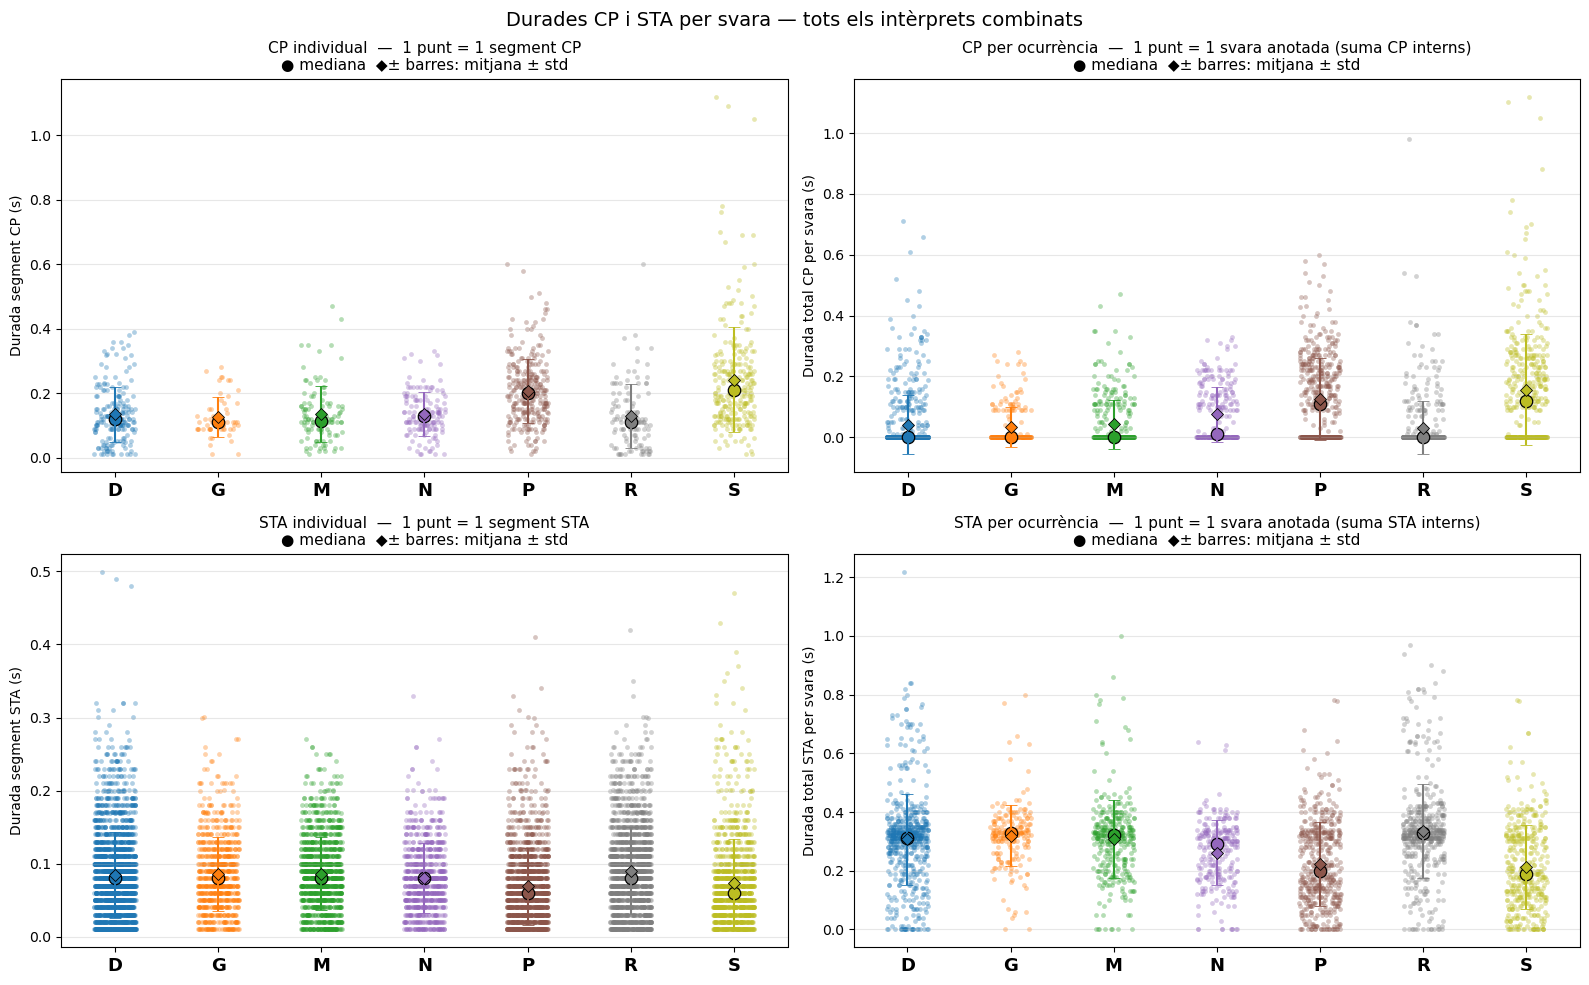

In [239]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

_scatter_combined(axes[0, 0], cp_ind_durs,
    ylabel='Durada segment CP (s)',
    title='CP individual  —  1 punt = 1 segment CP\n● mediana  ◆± barres: mitjana ± std')

_scatter_combined(axes[0, 1], cp_occ_durs,
    ylabel='Durada total CP per svara (s)',
    title='CP per ocurrència  —  1 punt = 1 svara anotada (suma CP interns)\n● mediana  ◆± barres: mitjana ± std')

_scatter_combined(axes[1, 0], sta_ind_durs,
    ylabel='Durada segment STA (s)',
    title='STA individual  —  1 punt = 1 segment STA\n● mediana  ◆± barres: mitjana ± std')

_scatter_combined(axes[1, 1], sta_occ_durs,
    ylabel='Durada total STA per svara (s)',
    title='STA per ocurrència  —  1 punt = 1 svara anotada (suma STA interns)\n● mediana  ◆± barres: mitjana ± std')

fig.suptitle('Durades CP i STA per svara — tots els intèrprets combinats', fontsize=14)
plt.tight_layout()
plt.show()

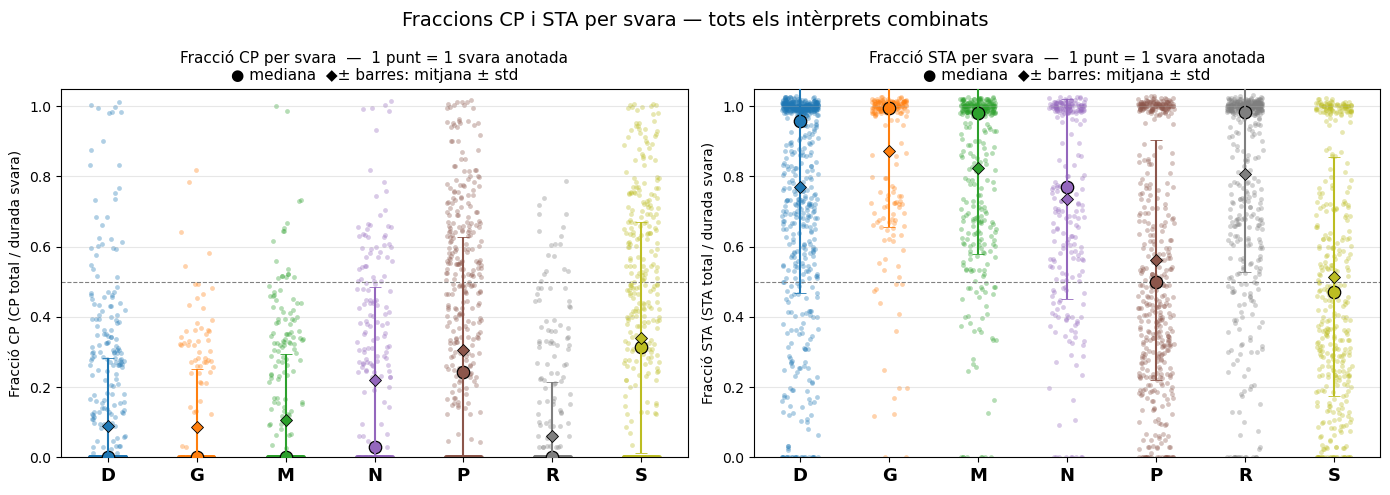

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

_scatter_combined(axes[0], cp_occ_frac,
    ylabel='Fracció CP (CP total / durada svara)',
    title='Fracció CP per svara  —  1 punt = 1 svara anotada\n● mediana  ◆± barres: mitjana ± std',
    ylim=(0, 1.05), hline=0.5)

_scatter_combined(axes[1], sta_occ_frac,
    ylabel='Fracció STA (STA total / durada svara)',
    title='Fracció STA per svara  —  1 punt = 1 svara anotada\n● mediana  ◆± barres: mitjana ± std',
    ylim=(0, 1.05), hline=0.5)

fig.suptitle('Fraccions CP i STA per svara — tots els intèrprets combinats', fontsize=14)
plt.tight_layout()
plt.show()

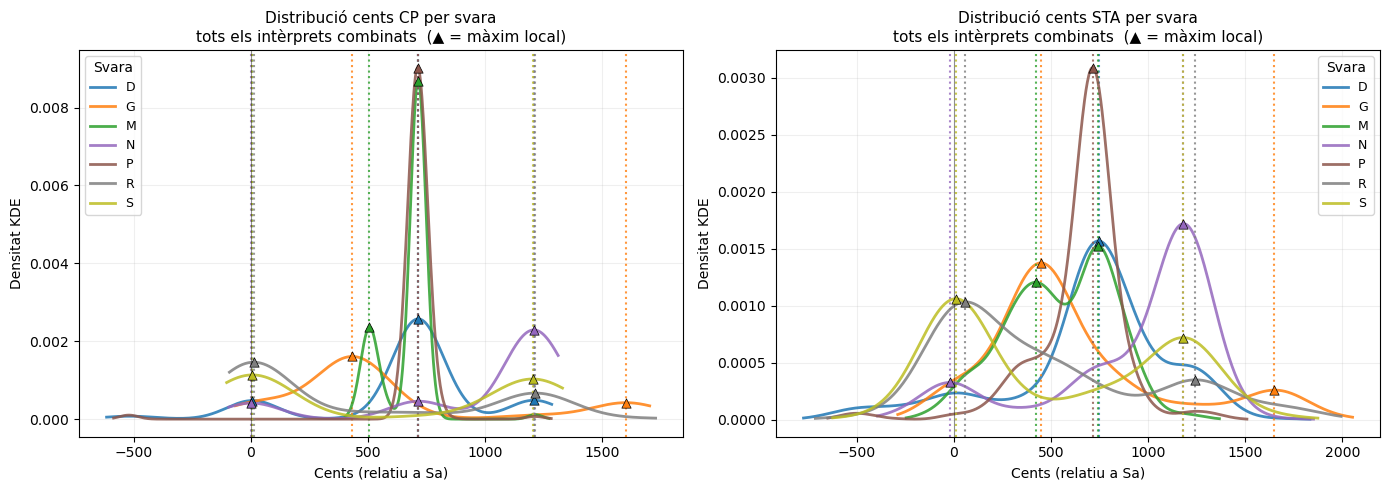

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cents_dict, label_type in [
    (axes[0], cp_cents_comb,  'CP'),
    (axes[1], sta_cents_comb, 'STA'),
]:
    for xi, sl in enumerate(svara_labels):
        vals = np.array(cents_dict[sl])
        vals = vals[np.isfinite(vals)]
        if len(vals) < 3:
            continue
        try:
            kde  = gaussian_kde(vals, bw_method=0.3)
            x    = np.linspace(vals.min() - 60, vals.max() + 60, 600)
            y    = kde(x)
            # Desplaça i escala la KDE per mostrar-la al costat de xi (violin-style horitzontal)
            # — o simplement la dibuixem com a subplot per svara —
            peaks, _ = find_peaks(y, height=0.15 * y.max(), distance=30)
            ax.plot(x, y + xi * 0.0, color=SVARA_COLORS[sl], linewidth=2, label=sl, alpha=0.85)
            for pk in peaks:
                ax.axvline(x[pk], color=SVARA_COLORS[sl], ls=':', lw=1.5, alpha=0.8)
                ax.scatter(x[pk], y[pk], color=SVARA_COLORS[sl], s=45, zorder=5,
                           marker='^', edgecolors='black', linewidths=0.5)
        except Exception:
            pass

    ax.axvline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_xlabel('Cents (relatiu a Sa)')
    ax.set_ylabel('Densitat KDE')
    ax.set_title(f'Distribució cents {label_type} per svara\ntots els intèrprets combinats  (▲ = màxim local)', fontsize=11)
    ax.legend(title='Svara', fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

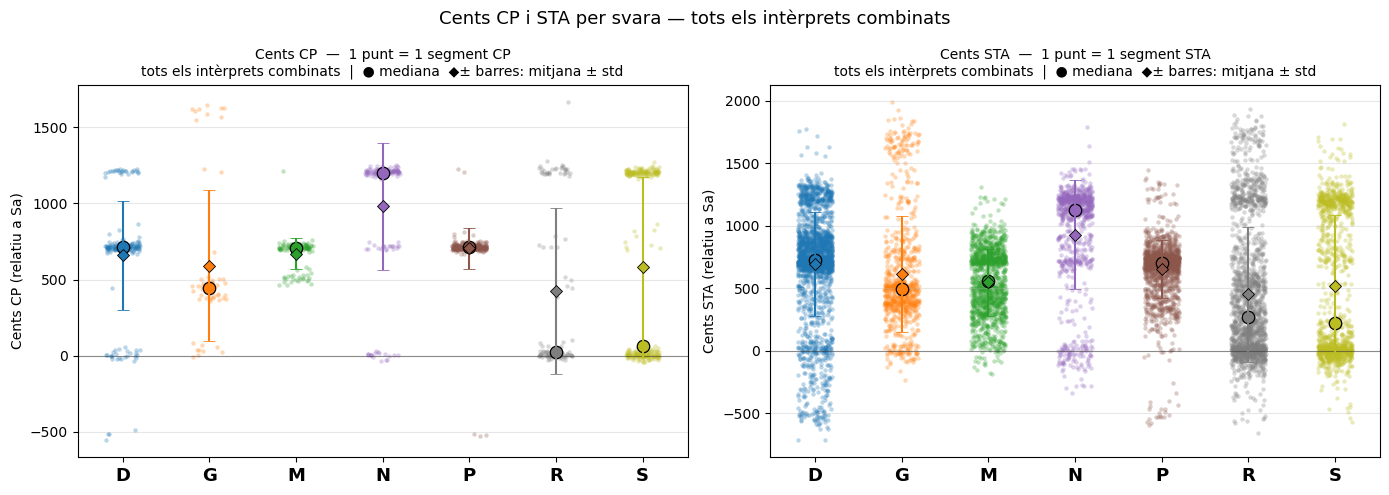

In [242]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cents_dict, seg_type in [
    (axes[0], cp_cents_comb,  'CP'),
    (axes[1], sta_cents_comb, 'STA'),
]:
    for xi, sl in enumerate(svara_labels):
        vals = np.array(cents_dict[sl], dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue

        jitter = np.random.default_rng(hash(sl + seg_type + 'cents') % 2**32).uniform(-0.2, 0.2, size=len(vals))
        ax.scatter(xi + jitter, vals, color=SVARA_COLORS[sl], alpha=0.3, s=10, linewidths=0)

        med, m, s = np.median(vals), np.mean(vals), np.std(vals)
        ax.scatter(xi, med, color=SVARA_COLORS[sl], s=80, zorder=5,
                   edgecolors='black', linewidths=0.9, marker='o')
        ax.errorbar(xi, m, yerr=s, fmt='D', color=SVARA_COLORS[sl],
                    markersize=6, capsize=4, capthick=1.5, elinewidth=1.5, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.6)

    ax.axhline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(f'Cents {seg_type} (relatiu a Sa)')
    ax.set_title(f'Cents {seg_type}  —  1 punt = 1 segment {seg_type}\n'
                 'tots els intèrprets combinats  |  ● mediana  ◆± barres: mitjana ± std', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Cents CP i STA per svara — tots els intèrprets combinats', fontsize=13)
plt.tight_layout()
plt.show()

### [C] Run-level — combined (all performers)
1 dot = 1 contiguous block of same type. All performers pooled.

In [ ]:
cp_run_durs_comb  = {sl: [] for sl in svara_labels}
sta_run_durs_comb = {sl: [] for sl in svara_labels}
sta_peak_comb     = {sl: [] for sl in svara_labels}
sta_valley_comb   = {sl: [] for sl in svara_labels}

for r in all_rows:
    sl = r['svara_label']
    if sl not in svara_labels:
        continue
    cp_run_durs_comb[sl].extend(r['cp_run_dur_list'])
    sta_run_durs_comb[sl].extend(r['sta_run_dur_list'])
    sta_peak_comb[sl].extend(r['sta_peak_cents_list'])
    sta_valley_comb[sl].extend(r['sta_valley_cents_list'])

# ── Run duration scatter ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, runs_dict, seg_type in [
    (axes[0], cp_run_durs_comb,  'CP'),
    (axes[1], sta_run_durs_comb, 'STA'),
]:
    for xi, sl in enumerate(svara_labels):
        vals = np.array(runs_dict[sl], dtype=float)
        vals = vals[np.isfinite(vals) & (vals > 0)]
        if len(vals) == 0:
            continue
        jitter = np.random.default_rng(hash(sl + seg_type + 'run') % 2**32).uniform(-0.2, 0.2, size=len(vals))
        ax.scatter(xi + jitter, vals, color=SVARA_COLORS[sl], alpha=0.3, s=10, linewidths=0)
        med, m, s = np.median(vals), np.mean(vals), np.std(vals)
        ax.scatter(xi, med, color=SVARA_COLORS[sl], s=80, zorder=5,
                   edgecolors='black', linewidths=0.9, marker='o')
        ax.errorbar(xi, m, yerr=s, fmt='D', color=SVARA_COLORS[sl],
                    markersize=6, capsize=4, capthick=1.5, elinewidth=1.5, zorder=6,
                    markeredgecolor='black', markeredgewidth=0.6)
    ax.set_xticks(range(len(svara_labels)))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_xlim(-0.5, n_s - 0.5)
    ax.set_ylabel(f'Durada run {seg_type} (s)')
    ax.set_title(f'[C] {seg_type} run duration — combined\n1 punt = 1 contiguous block  |  ● mediana  ◆± std', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('[C] Run duration CP i STA — tots els intèrprets combinats', fontsize=13)
plt.tight_layout()
plt.show()

# ── STA peak vs valley histogram — combined ───────────────────────────────────
fig, axes = plt.subplots(1, n_s, figsize=(3.5 * n_s, 4), sharey=False)
if n_s == 1:
    axes = [axes]

for ax, sl in zip(axes, svara_labels):
    p_arr = np.array(sta_peak_comb[sl],   dtype=float); p_arr = p_arr[np.isfinite(p_arr)]
    v_arr = np.array(sta_valley_comb[sl], dtype=float); v_arr = v_arr[np.isfinite(v_arr)]
    all_v = np.concatenate([p_arr, v_arr])
    if len(all_v) == 0:
        continue
    bins = np.linspace(all_v.min() - 30, all_v.max() + 30, 30)
    ax.hist(p_arr, bins=bins, color=COLOR_PEAK,   alpha=0.65, edgecolor='white', lw=0.4, label='Peak')
    ax.hist(v_arr, bins=bins, color=COLOR_VALLEY, alpha=0.65, edgecolor='white', lw=0.4, label='Valley')
    x = np.linspace(all_v.min() - 60, all_v.max() + 60, 400)
    bw = bins[1] - bins[0]
    try:
        if len(p_arr) >= 3:
            ax.plot(x, gaussian_kde(p_arr, bw_method=0.3)(x) * len(p_arr) * bw, color=COLOR_PEAK, lw=2)
        if len(v_arr) >= 3:
            ax.plot(x, gaussian_kde(v_arr, bw_method=0.3)(x) * len(v_arr) * bw, color=COLOR_VALLEY, lw=2)
    except Exception:
        pass
    ax.axvline(0, color='black', lw=0.8, alpha=0.4)
    ax.set_title(sl, fontsize=14, fontweight='bold')
    ax.set_xlabel('Cents')
    ax.set_ylabel('Compte')
    ax.text(0.97, 0.97, f'p={len(p_arr)}\nv={len(v_arr)}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='gray')

axes[0].legend(fontsize=9)
fig.suptitle('[D] STA peak vs valley — combined, tots els intèrprets', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 1 — Global Discriminative Power (Mutual Information)

Per each descriptor, compute **MI(descriptor, svara_label)** across all individual svara occurrences (2760 rows).

`mutual_info_classif` estimates MI between each continuous feature and the discrete class label.

Runs:
- **All features** — structural + pitch (cents)
- **Structural only** — no pitch information

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# ── Feature definitions ──────────────────────────────────────────────────────
# [A] segment-level  [B] occurrence-level totals  [C] run-level  [D] pitch
STRUCT_FEATS = [
    'svara_dur_sec',                           # [B] total svara duration
    'n_cp',   'cp_total_dur_sec', 'cp_frac',   # [A/B] CP segment count + totals
    'n_sta',  'sta_total_dur_sec','sta_frac',   # [A/B] STA segment count + totals
    'sil_total_dur_sec',                        # [B] SIL total
    'n_cp_runs',  'cp_run_mean_dur',            # [C] CP run structure
    'n_sta_runs', 'sta_run_mean_dur',           # [C] STA run structure
]
PITCH_FEATS = ['cp_mean_cents', 'sta_mean_cents']
ALL_FEATS   = STRUCT_FEATS + PITCH_FEATS

FEAT_LABELS = {
    'svara_dur_sec':    '[B] Svara duration (s)',
    'n_cp':             '[A] N° CP segments',
    'cp_total_dur_sec': '[B] CP total duration (s)',
    'cp_frac':          '[B] CP fraction',
    'n_sta':            '[A] N° STA segments',
    'sta_total_dur_sec':'[B] STA total duration (s)',
    'sta_frac':         '[B] STA fraction',
    'sil_total_dur_sec':'[B] SIL total duration (s)',
    'n_cp_runs':        '[C] N° CP runs',
    'cp_run_mean_dur':  '[C] CP run mean dur (s)',
    'n_sta_runs':       '[C] N° STA runs',
    'sta_run_mean_dur': '[C] STA run mean dur (s)',
    'cp_mean_cents':    '[D] CP mean cents',
    'sta_mean_cents':   '[D] STA mean cents',
}

# ── Build feature matrix ─────────────────────────────────────────────────────
df_pd = df.to_pandas()
y     = df_pd['svara_label'].values

X_all = df_pd[ALL_FEATS].copy()
for col in PITCH_FEATS + ['cp_run_mean_dur', 'sta_run_mean_dur']:
    X_all[col] = X_all[col].fillna(X_all[col].median())

X_struct = X_all[STRUCT_FEATS]

# ── Compute MI ───────────────────────────────────────────────────────────────
mi_all    = mutual_info_classif(X_all.values,    y, random_state=42)
mi_struct = mutual_info_classif(X_struct.values, y, random_state=42)

mi_all_dict    = dict(zip(ALL_FEATS,    mi_all))
mi_struct_dict = dict(zip(STRUCT_FEATS, mi_struct))

print('[Step 1] MI(descriptor, svara_label) — all features, sorted:')
for f, v in sorted(mi_all_dict.items(), key=lambda x: -x[1]):
    print(f'  {FEAT_LABELS[f]:<32s}  {v:.4f}')

print('\n[Step 1] MI — structural only:')
for f, v in sorted(mi_struct_dict.items(), key=lambda x: -x[1]):
    print(f'  {FEAT_LABELS[f]:<32s}  {v:.4f}')

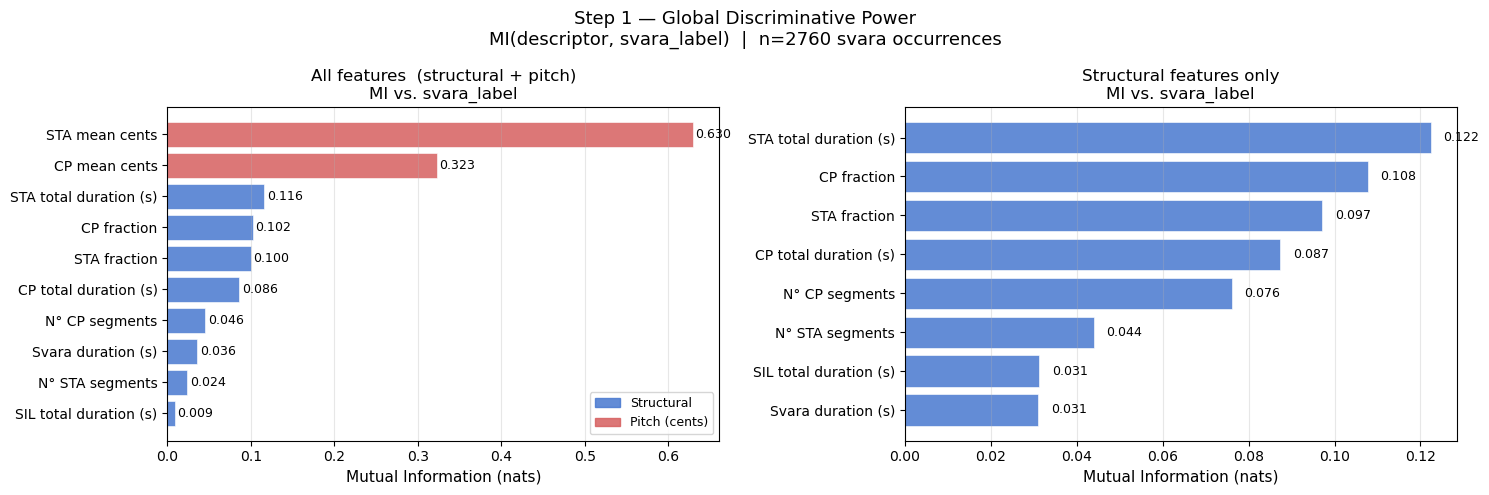

In [244]:
# ── Plot: MI bar chart (two runs side by side) ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

COLOR_STRUCT = '#4878cf'
COLOR_PITCH  = '#d65f5f'

# — Left: ALL features, sorted by MI descending —
ax = axes[0]
feats_sorted = sorted(ALL_FEATS, key=lambda f: -mi_all_dict[f])
vals  = [mi_all_dict[f] for f in feats_sorted]
cols  = [COLOR_PITCH if f in PITCH_FEATS else COLOR_STRUCT for f in feats_sorted]
names = [FEAT_LABELS[f] for f in feats_sorted]

bars = ax.barh(range(len(feats_sorted)), vals, color=cols, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feats_sorted)))
ax.set_yticklabels(names, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information (nats)', fontsize=11)
ax.set_title('All features  (structural + pitch)\nMI vs. svara_label', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, vals):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9)

legend_handles = [
    mpatches.Patch(color=COLOR_STRUCT, label='Structural', alpha=0.85),
    mpatches.Patch(color=COLOR_PITCH,  label='Pitch (cents)', alpha=0.85),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

# — Right: STRUCTURAL only, sorted by MI descending —
ax = axes[1]
feats_sorted_s = sorted(STRUCT_FEATS, key=lambda f: -mi_struct_dict[f])
vals_s  = [mi_struct_dict[f] for f in feats_sorted_s]
names_s = [FEAT_LABELS[f] for f in feats_sorted_s]

bars_s = ax.barh(range(len(feats_sorted_s)), vals_s, color=COLOR_STRUCT, alpha=0.85,
                 edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feats_sorted_s)))
ax.set_yticklabels(names_s, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mutual Information (nats)', fontsize=11)
ax.set_title('Structural features only\nMI vs. svara_label', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars_s, vals_s):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9)

fig.suptitle('Step 1 — Global Discriminative Power\nMI(descriptor, svara_label)  |  n=2760 svara occurrences', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 2 — Per-Performer Consistency

For each performer, compute **MI(descriptor, svara_label)** on that performer's occurrences only.

- **Low std across performers** → descriptor behaves the same for every performer → candidate invariant
- **High std across performers** → discriminative power depends on who plays

In [ ]:
# ── MI per performer ─────────────────────────────────────────────────────────
mi_per_perf = {}   # {perf: {feat: mi_val}}

for perf in performers:
    sub   = df_pd[df_pd['performer'] == perf].copy()
    y_p   = sub['svara_label'].values
    X_p   = sub[ALL_FEATS].copy()
    for col in PITCH_FEATS:
        X_p[col] = X_p[col].fillna(X_p[col].median())

    mi_p = mutual_info_classif(X_p.values, y_p, random_state=42)
    mi_per_perf[perf] = dict(zip(ALL_FEATS, mi_p))
    print(f'{perf}  (n={len(sub)}):  '
          + '  '.join(f'{FEAT_LABELS[f][:12]}={mi_per_perf[perf][f]:.3f}' for f in ALL_FEATS))

# ── Consistency summary ──────────────────────────────────────────────────────
import pandas as pd

mi_df = pd.DataFrame(mi_per_perf).T   # shape (n_performers, n_feats)
consistency = pd.DataFrame({
    'mean_MI': mi_df.mean(),
    'std_MI':  mi_df.std(),
    'cv_MI':   mi_df.std() / (mi_df.mean() + 1e-9),   # coefficient of variation
}).sort_values('mean_MI', ascending=False)

print('\nConsistency table (sorted by mean MI desc):')
print(consistency.to_string(float_format='{:.4f}'.format))

In [ ]:
# ── Plot A: heatmap (features × performers) ──────────────────────────────────
feats_by_mean = consistency.index.tolist()   # sorted by mean MI desc

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         gridspec_kw={'width_ratios': [2.2, 1.2, 1.2]})

# ─ Left: heatmap MI per performer ─
ax = axes[0]
mat = np.array([[mi_per_perf[p][f] for p in performers] for f in feats_by_mean])
norm_h = mcolors.Normalize(vmin=0, vmax=mat.max())
im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', norm=norm_h)
ax.set_xticks(range(len(performers)))
ax.set_xticklabels(performers, fontsize=11)
ax.set_yticks(range(len(feats_by_mean)))
ax.set_yticklabels([FEAT_LABELS[f] for f in feats_by_mean], fontsize=10)
ax.set_title('MI(descriptor, svara_label)\nper performer', fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.8, label='MI (nats)')

cmap_h = plt.cm.YlOrRd
for i, f in enumerate(feats_by_mean):
    for j, p in enumerate(performers):
        v = mat[i, j]
        rgba = cmap_h(norm_h(v))
        lum  = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center', fontsize=8,
                color='black' if lum > 0.45 else 'white')

# ─ Middle: mean MI + per-performer dots ─
ax = axes[1]
for i, f in enumerate(feats_by_mean):
    per_vals = [mi_per_perf[p][f] for p in performers]
    ax.errorbar(consistency.loc[f, 'mean_MI'], i,
                xerr=consistency.loc[f, 'std_MI'],
                fmt='s', color='#4878cf', markersize=6,
                capsize=3, capthick=1.5, elinewidth=1.5,
                markeredgecolor='black', markeredgewidth=0.5, zorder=5)
    for pi, (p, v) in enumerate(zip(performers, per_vals)):
        ax.scatter(v, i, color=COLORS.get(p, 'gray'), s=30, zorder=6,
                   edgecolors='black', linewidths=0.4, alpha=0.85)

ax.set_yticks(range(len(feats_by_mean)))
ax.set_yticklabels([FEAT_LABELS[f] for f in feats_by_mean], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('MI (nats)', fontsize=10)
ax.set_title('Mean ± std\n(dots = each performer)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.axvline(0, color='black', lw=0.6, alpha=0.4)
perf_legend = [mpatches.Patch(color=COLORS.get(p, 'gray'), label=p) for p in performers]
ax.legend(handles=perf_legend, fontsize=8, loc='lower right')

# ─ Right: coefficient of variation (CV = std/mean) — lower = more consistent ─
ax = axes[2]
cv_sorted = consistency['cv_MI'].values
mean_sorted = consistency['mean_MI'].values
bar_colors = ['#2ca02c' if v < 0.5 else '#ff7f0e' if v < 1.0 else '#d62728'
              for v in cv_sorted]

bars = ax.barh(range(len(feats_by_mean)), cv_sorted,
               color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feats_by_mean)))
ax.set_yticklabels([FEAT_LABELS[f] for f in feats_by_mean], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('CV = std / mean  (lower = more consistent)', fontsize=10)
ax.set_title('Consistency across performers\n(CV)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
ax.axvline(0.5, color='#ff7f0e', ls='--', lw=1, alpha=0.7, label='CV=0.5')
ax.axvline(1.0, color='#d62728', ls='--', lw=1, alpha=0.7, label='CV=1.0')
ax.legend(fontsize=8)
for bar, v in zip(bars, cv_sorted):
    ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}', va='center', fontsize=8)

fig.suptitle('Step 2 — Per-Performer Consistency of MI(descriptor, svara_label)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 3 — Dependence on Performer

For each descriptor, compute **MI(descriptor, performer)** across all occurrences.

- **High MI** → descriptor carries information about who is playing → not invariant
- **Low MI** → descriptor is blind to performer identity → invariant candidate

In [ ]:
# ── MI(descriptor, performer) ────────────────────────────────────────────────
y_perf = df_pd['performer'].values

mi_perf_all    = mutual_info_classif(X_all.values,    y_perf, random_state=42)
mi_perf_struct = mutual_info_classif(X_struct.values, y_perf, random_state=42)

mi_perf_all_dict    = dict(zip(ALL_FEATS,    mi_perf_all))
mi_perf_struct_dict = dict(zip(STRUCT_FEATS, mi_perf_struct))

print('MI(descriptor, performer) — all features, sorted:')
for f, v in sorted(mi_perf_all_dict.items(), key=lambda x: -x[1]):
    svara_mi = mi_all_dict[f]
    ratio    = svara_mi / (v + 1e-9)
    print(f'  {FEAT_LABELS[f]:<30s}  performer={v:.4f}  svara={svara_mi:.4f}  ratio={ratio:.1f}x')

In [ ]:
# ── Plot: three panels ───────────────────────────────────────────────────────
# Features sorted by MI(descriptor, performer) descending (most performer-dependent first)
feats_by_perf = sorted(ALL_FEATS, key=lambda f: -mi_perf_all_dict[f])

fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                         gridspec_kw={'width_ratios': [1.4, 1.4, 1.4]})

bar_cols = [COLOR_PITCH if f in PITCH_FEATS else COLOR_STRUCT for f in feats_by_perf]
names_p  = [FEAT_LABELS[f] for f in feats_by_perf]

# ─ Left: MI(descriptor, performer) ─
ax = axes[0]
vals_p = [mi_perf_all_dict[f] for f in feats_by_perf]
bars = ax.barh(range(len(feats_by_perf)), vals_p, color=bar_cols, alpha=0.85,
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feats_by_perf)))
ax.set_yticklabels(names_p, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('MI (nats)', fontsize=11)
ax.set_title('MI(descriptor, performer)\n↑ high = performer-dependent', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, vals_p):
    ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color=COLOR_STRUCT, label='Structural', alpha=0.85),
    mpatches.Patch(color=COLOR_PITCH,  label='Pitch (cents)', alpha=0.85),
], fontsize=9, loc='lower right')

# ─ Middle: MI(descriptor, svara_label) on the same feature order ─
ax = axes[1]
vals_s = [mi_all_dict[f] for f in feats_by_perf]
bars_s = ax.barh(range(len(feats_by_perf)), vals_s, color=bar_cols, alpha=0.85,
                 edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feats_by_perf)))
ax.set_yticklabels(names_p, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('MI (nats)', fontsize=11)
ax.set_title('MI(descriptor, svara_label)\n(same feature order)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars_s, vals_s):
    ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9)

# ─ Right: scatter MI(svara) vs MI(performer) — invariance map ─
ax = axes[2]
for f in ALL_FEATS:
    x = mi_perf_all_dict[f]
    y = mi_all_dict[f]
    color = COLOR_PITCH if f in PITCH_FEATS else COLOR_STRUCT
    ax.scatter(x, y, color=color, s=60, zorder=5,
               edgecolors='black', linewidths=0.6, alpha=0.9)
    ax.annotate(FEAT_LABELS[f], (x, y),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7.5, alpha=0.9)

# Diagonal: MI(svara) == MI(performer) — below is "more svara than performer"
lim = max(max(mi_perf_all_dict.values()), max(mi_all_dict.values())) * 1.15
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.4, label='MI equal')
ax.fill_between([0, lim], [0, 0], [0, lim], alpha=0.04, color='green')
ax.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.04, color='red')
ax.text(lim * 0.65, lim * 0.85, 'svara > performer\n(invariant zone)',
        fontsize=8, color='green', alpha=0.7)
ax.text(lim * 0.35, lim * 0.1, 'performer > svara\n(style zone)',
        fontsize=8, color='firebrick', alpha=0.7)

ax.set_xlim(-0.01, lim)
ax.set_ylim(-0.01, lim)
ax.set_xlabel('MI(descriptor, performer)  →  performer dependence', fontsize=10)
ax.set_ylabel('MI(descriptor, svara_label)  →  discriminative power', fontsize=10)
ax.set_title('Invariance map\n(want: top-left quadrant)', fontsize=12)
ax.grid(alpha=0.2)
ax.legend(handles=[
    mpatches.Patch(color=COLOR_STRUCT, label='Structural', alpha=0.85),
    mpatches.Patch(color=COLOR_PITCH,  label='Pitch (cents)', alpha=0.85),
], fontsize=9)

fig.suptitle('Step 3 — Performer Dependence  |  MI(descriptor, performer)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 4 — Invariance Score

Combined score per descriptor:

`inv_score = disc_norm × (1 − perf_norm)`

where `disc_norm = MI(d, svara) / max_svara` and `perf_norm = MI(d, performer) / max_perf`, both in [0, 1].

→ **High score**: discriminative AND performer-independent  
→ **Low score**: either weak or too performer-specific

In [ ]:
eps = 1e-9

max_svara = max(mi_all_dict.values())
max_perf  = max(mi_perf_all_dict.values())

disc_norm = {f: mi_all_dict[f]      / max_svara for f in ALL_FEATS}
perf_norm = {f: mi_perf_all_dict[f] / max_perf  for f in ALL_FEATS}
inv_norm  = {f: 1.0 - perf_norm[f]              for f in ALL_FEATS}
inv_score = {f: disc_norm[f] * inv_norm[f]       for f in ALL_FEATS}

# ── Classification (data-driven thresholds: median disc_norm, median perf_norm) ──
disc_vals = list(disc_norm.values())
perf_vals = list(perf_norm.values())
disc_thr = float(np.median(disc_vals))   # features above median discriminability
perf_thr = float(np.median(perf_vals))   # features below median performer dependence

def classify(f):
    d = disc_norm[f]
    p = perf_norm[f]
    if d >= disc_thr and p < perf_thr:
        return 'Invariant & discriminative'
    elif d >= disc_thr and p >= perf_thr:
        return 'Discriminative but performer-dependent'
    else:
        return 'Weak / non-informative'

import pandas as pd
summary = pd.DataFrame({
    'MI_svara':     {f: mi_all_dict[f]      for f in ALL_FEATS},
    'MI_performer': {f: mi_perf_all_dict[f] for f in ALL_FEATS},
    'disc_norm':    disc_norm,
    'perf_norm':    perf_norm,
    'inv_score':    inv_score,
    'category':     {f: classify(f) for f in ALL_FEATS},
}).sort_values('inv_score', ascending=False)
summary.index = [FEAT_LABELS[f] for f in summary.index]

print(f'Thresholds: disc_norm ≥ {disc_thr:.3f}, perf_norm < {perf_thr:.3f}\n')
print(summary[['MI_svara','MI_performer','disc_norm','perf_norm','inv_score','category']]
      .to_string(float_format='{:.4f}'.format))

In [ ]:
CAT_COLORS = {
    'Invariant & discriminative':           '#2ca02c',
    'Discriminative but performer-dependent':'#ff7f0e',
    'Weak / non-informative':               '#aec7e8',
}

feats_ranked = sorted(ALL_FEATS, key=lambda f: -inv_score[f])

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [1.5, 1.3]})

# ─ Left: inv_score bar chart ─
ax = axes[0]
vals_is  = [inv_score[f] for f in feats_ranked]
bar_cats = [classify(f) for f in feats_ranked]
bar_c    = [CAT_COLORS[c] for c in bar_cats]
names_r  = [FEAT_LABELS[f] for f in feats_ranked]

bars = ax.barh(range(len(feats_ranked)), vals_is, color=bar_c, alpha=0.88,
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(feats_ranked)))
ax.set_yticklabels(names_r, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Invariance score  =  disc_norm × (1 − perf_norm)', fontsize=11)
ax.set_title('Step 4 — Invariance Score\n(ranked, color = category)', fontsize=12)
ax.grid(axis='x', alpha=0.3)
for bar, v in zip(bars, vals_is):
    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9)

cat_legend = [mpatches.Patch(color=c, label=k, alpha=0.88)
              for k, c in CAT_COLORS.items()]
ax.legend(handles=cat_legend, fontsize=8, loc='lower right')

# ─ Right: 2D invariance map, bubble = inv_score ─
ax = axes[1]
for f in ALL_FEATS:
    x     = mi_perf_all_dict[f]
    y     = mi_all_dict[f]
    score = inv_score[f]
    cat   = classify(f)
    color = CAT_COLORS[cat]
    size  = 80 + 800 * score   # bubble proportional to score
    ax.scatter(x, y, s=size, color=color, alpha=0.82,
               edgecolors='black', linewidths=0.7, zorder=5)
    ax.annotate(FEAT_LABELS[f], (x, y),
                textcoords='offset points', xytext=(6, 3), fontsize=7.5)

lim = max(max(mi_perf_all_dict.values()), max(mi_all_dict.values())) * 1.15
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.35)
ax.set_xlim(-0.01, lim)
ax.set_ylim(-0.01, lim)
ax.axvline(max_perf * perf_thr,  ls=':', color='gray', lw=1, alpha=0.6,
           label=f'perf_norm={perf_thr:.2f}')
ax.axhline(max_svara * disc_thr, ls=':', color='gray', lw=1, alpha=0.6,
           label=f'disc_norm={disc_thr:.2f}')
ax.set_xlabel('MI(descriptor, performer)  →  performer dependence', fontsize=10)
ax.set_ylabel('MI(descriptor, svara_label)  →  discriminative power', fontsize=10)
ax.set_title('Invariance map  (bubble size ∝ inv_score)', fontsize=12)
ax.grid(alpha=0.2)
ax.legend(handles=cat_legend + ax.get_legend_handles_labels()[0][-2:],
          fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

---
## Step 5 — Qualitative Validation

For the top-ranked features (by invariance score), check visually:
- **Compactness**: are within-svara distributions tight?
- **Separation**: are between-svara distributions distinct?
- **Stability**: do per-performer medians stay close together?

Violin = overall distribution per svara. Colored dots = per-performer median.

In [ ]:
# Top-ranked structural features + top pitch feature
top_struct = sorted(STRUCT_FEATS, key=lambda f: -inv_score[f])[:4]
top_pitch  = sorted(PITCH_FEATS,  key=lambda f: -inv_score[f])[:2]
top_feats  = top_struct + top_pitch   # 6 panels

ncols = 3
nrows = int(np.ceil(len(top_feats) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 5 * nrows), squeeze=False)

for idx, f in enumerate(top_feats):
    ax = axes[idx // ncols][idx % ncols]
    cat = classify(f)

    # ── Violin per svara (all performers combined) ──
    data_per_svara = []
    for sl in svara_labels:
        vals = df_pd[df_pd['svara_label'] == sl][f].dropna().values
        data_per_svara.append(vals if len(vals) > 1 else np.array([np.nan]))

    parts = ax.violinplot(
        [v[np.isfinite(v)] for v in data_per_svara],
        positions=range(n_s),
        showmedians=True, showextrema=False, widths=0.7,
    )
    for pc, sl in zip(parts['bodies'], svara_labels):
        pc.set_facecolor(SVARA_COLORS[sl])
        pc.set_alpha(0.55)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(1.5)

    # ── Per-performer medians (dots) ──
    for xi, sl in enumerate(svara_labels):
        for perf in performers:
            sub = df_pd[(df_pd['svara_label'] == sl) &
                        (df_pd['performer'] == perf)][f].dropna()
            if len(sub) == 0:
                continue
            ax.scatter(xi, sub.median(), color=COLORS.get(perf, 'gray'),
                       s=35, zorder=6, edgecolors='black', linewidths=0.5, alpha=0.9)

    ax.set_xticks(range(n_s))
    ax.set_xticklabels(svara_labels, fontsize=13, fontweight='bold')
    ax.set_ylabel(FEAT_LABELS[f], fontsize=10)
    ax.set_title(f'{FEAT_LABELS[f]}\n[{cat}]',
                 fontsize=10, color=CAT_COLORS[cat], fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    score_txt = f'inv_score={inv_score[f]:.3f}'
    ax.text(0.98, 0.97, score_txt, transform=ax.transAxes,
            fontsize=8, ha='right', va='top', color='gray')

# Hide empty axes
for idx in range(len(top_feats), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

# Shared legend
perf_legend = [mpatches.Patch(color=COLORS.get(p, 'gray'), label=p) for p in performers]
fig.legend(handles=perf_legend, title='Performer (dot = median)',
           loc='lower right', fontsize=9, ncol=len(performers))

fig.suptitle('Step 5 — Distribution per svara for top-ranked features\n'
             'Violin = all performers combined  |  Dot = per-performer median',
             fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Final classification table ───────────────────────────────────────────────
print('=' * 72)
print(f'{"FINAL DESCRIPTOR CLASSIFICATION":^72}')
print('=' * 72)
print(f'  Thresholds: disc_norm ≥ {disc_thr:.3f} | perf_norm < {perf_thr:.3f}')
print()

for cat in CAT_COLORS:
    feats_in_cat = [f for f in ALL_FEATS if classify(f) == cat]
    feats_in_cat_s = sorted(feats_in_cat, key=lambda f: -inv_score[f])
    print(f'  ▸ {cat}')
    for f in feats_in_cat_s:
        pitch_tag = '  [pitch]' if f in PITCH_FEATS else ''
        print(f'      {FEAT_LABELS[f]:<30s}  score={inv_score[f]:.3f}'
              f'  MI_svara={mi_all_dict[f]:.4f}'
              f'  MI_perf={mi_perf_all_dict[f]:.4f}{pitch_tag}')
    print()

print('─' * 72)
print()
print('KEY CLAIMS:')
print()
print('  1. Structure alone (without pitch) carries discriminative information.')
top_s = sorted(STRUCT_FEATS, key=lambda f: -mi_struct_dict[f])
for f in top_s[:3]:
    print(f'     → {FEAT_LABELS[f]}: MI_svara(struct)={mi_struct_dict[f]:.4f}')
print()
print('  2. Descriptors classified as "Invariant & discriminative":')
inv_disc = [f for f in ALL_FEATS if classify(f) == 'Invariant & discriminative']
for f in sorted(inv_disc, key=lambda f: -inv_score[f]):
    print(f'     → {FEAT_LABELS[f]}: score={inv_score[f]:.3f}')
print()
print('  3. Descriptors influenced by performance style:')
perf_dep = [f for f in ALL_FEATS if classify(f) == 'Discriminative but performer-dependent']
for f in sorted(perf_dep, key=lambda f: -mi_perf_all_dict[f]):
    print(f'     → {FEAT_LABELS[f]}: MI_perf={mi_perf_all_dict[f]:.4f}')